# The variational quantum eigensolver — ground states of spin chains from a trained circuit

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

The central computational problem of quantum many-body physics is the **ground state**: the eigenvector of the
Hamiltonian with the lowest eigenvalue. Magnetic order, superconductivity, the binding energy of a molecule and the
phase diagram of a spin chain are all read off from it. Exact diagonalisation gives it for $N\lesssim20$ spins and
then stops, because the Hilbert-space dimension is $2^N$.

The **variational quantum eigensolver** (VQE) is one answer to that wall. It replaces the eigenvalue problem by a
minimisation: pick a family of states $\vert\psi(\boldsymbol\theta)\rangle$ that a quantum device can prepare, measure
the energy $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle$, and let a
classical optimiser push $\boldsymbol\theta$ downhill. The variational principle guarantees that whatever the optimiser
finds is an upper bound on the true ground energy $E_0$, so the method cannot lie in the dangerous direction: it can
only be *too high*.

```text
    |0...0>  --->  U(theta)  --->  |psi(theta)>  --->  measure <H>  --->  E(theta)
                       ^                                                    |
                       +------------- classical optimiser <-----------------+
```

The algorithm was first demonstrated on a photonic chip (Peruzzo *et al.*, 2014), was run on up to six
superconducting qubits for small molecules and a quantum magnet with a hardware-efficient circuit (Kandala *et al.*,
2017), and is one of the most studied applications of noisy intermediate-scale devices (Tilly *et al.*, 2022).

**What this notebook does.** We run the complete algorithm on a simulator, where the exact answer is available from
Lanczos, and we ask the questions that only a simulator can answer:

* the energy converges — but does the **state**? We derive and then measure the two inequalities that connect the
  energy error to the fidelity, and find that the energy error is *second order* in the state error while being bounded
  below by (gap) $\times$ (infidelity) when the ground state is unique;
* the Hamiltonians have a symmetry; the ansatz does not. We measure how much symmetry the optimised state leaks;
* how does the error depend on the number of layers, and is the limit expressivity or trainability?
* across the phase diagram of the transverse-field Ising chain, where is VQE hard — and what does "fidelity" even mean
  in a phase with a nearly degenerate ground doublet?
* how does one get an *excited* state out of a method built to minimise?
* with a finite measurement budget, which optimiser gets further per shot?

**Road map.** Section 3 proves the variational principle and the two error relations, and measures them. Section 4
fixes the three Hamiltonians and their exact references. Section 5 treats symmetry. Sections 6 to 8 build and run the
VQE loop and produce the nine-panel metric comparison against the exact ground state. Sections 9 to 13 are the studies:
symmetry leakage, depth, the phase diagram, deflation for the first excited state, and shot noise at equal budget.
Section 14 lists the limits of what was shown.

### What you will learn

*Physics*

* the Rayleigh-Ritz variational principle with its proof, and why it makes an upper bound on $E_0$ free;
* why the energy error is quadratic in the state error, and why a small energy error certifies a high fidelity only
  through the spectral gap $\Delta$: $E-E_0\ge\Delta\,(1-F)$ for a unique ground state, so that near a degeneracy an
  energy error of $2\cdot10^{-4}$ coexists with a fidelity of $1/2$;
* what a $\mathbb Z_2$ symmetry of a spin chain is, why the hardware-efficient ansatz breaks it, and what
  symmetry breaking means for a finite chain with an exponentially small gap;
* the physics of the transverse-field Ising chain across its transition at $N=6$: the doublet splitting closes
  exponentially in the ordered phase, the half-chain entropy of a short open chain is largest in the ordered phase
  (one bit of cat-state entanglement) rather than at the critical point, and a variational state can have a tiny
  energy error and fidelity $\approx1/2$.

*Numerical methods*

* the VQE loop as a compiled `lax.scan` with statistics over random initialisations, never a single run;
* variational quantum deflation: an orthogonality penalty that turns a minimiser into an excited-state solver, and the
  condition on the penalty strength;
* the entanglement a depth-$L$ nearest-neighbour circuit can carry across a cut, derived as a bound and measured;
* a fair comparison of gradient methods at equal *measurement budget* rather than at equal iteration count.

*Implementation practice*

* making the Hamiltonian coefficients **traced** arguments so that one compiled program serves three models, or a
  whole magnetic-field sweep;
* a vector-valued `monitor` inside the training scan, so that nine physical observables are recorded per iteration at
  the cost of one compilation;
* validating every reference: Lanczos against dense diagonalisation, matrix-free energies against explicit matrix
  elements, and a symmetry against a matrix-free commutator.

### Prerequisites

* [40 — parametrized gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb):
  ansätze, cost functions, the parameter-shift rule, SPSA, `jax.grad` through a circuit, barren plateaus;
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): Adam, SPSA with Spall gains, the
  `lax.scan` training loop, `vmap` over random initialisations, and the overparametrisation threshold;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Hamiltonians as lists of local terms, and the Lanczos ground state that is our reference throughout;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, entanglement entropy, fidelity;
* [42a — VQE: Hamiltonians, ansätze and training](../ch11_variational_quantum_circuits/42a_variational_quantum_eigensolver_hamiltonians_ansatze_training.ipynb):
  the first VQE notebook, read before this one. Its antiferromagnetic XXZ chain without a field and its Ising field
  $-h\sum_iX_i$ differ from the models of Section 4.1, which have ferromagnetic couplings and a field $+h_x\sum_iX_i$.

**Conventions and sizes.** Qubit $q$ is tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. Hamiltonians
are written in the Pauli convention (Section 4.1), never with spin-$1/2$ operators. The main studies use $N=6$ spins so
that twelve random restarts times three models times three hundred iterations fit into one compiled program; the
shot-noise study uses $N=4$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the gate application and rotations, the hardware-efficient ansatz with its parameter count,
the Hamiltonian machinery (`heisenberg_terms`, `energy`, `dense_hamiltonian`, `lanczos_ground_state`), the state
characteristics (`entanglement_entropy`, `fidelity_pure`, `all_local_expectations`, `expect_pauli_string`) and
`sample_bitstrings` for the shot-noise section. The optimiser and training-loop helpers are the ones built in
[41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb) and are repeated here so that this notebook
runs on its own.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def parameter_shift_grad(f, theta, shift=jnp.pi / 2):
    """Parameter-shift rule: for gates exp(-i theta_k P/2) with P^2 = 1 the cost is a sinusoid in theta_k,
        f = a + b cos(theta_k) + c sin(theta_k),   so for any shift s with sin(s) != 0
        d f / d theta_k = [ f(theta + s e_k) - f(theta - s e_k) ] / (2 sin s)          (EXACT, not finite differences)
    and the default s = pi/2 gives the familiar [ f(+pi/2) - f(-pi/2) ] / 2.
    -- the gradient a real quantum computer can measure: 2 circuit evaluations per parameter.
    JAX: vmap over the unit vectors e_k evaluates all shifted circuits in one batched call."""
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)
    denom = 2 * jnp.sin(shift)
    return jax.vmap(lambda e: (f(theta + shift * e) - f(theta - shift * e)) / denom)(eye).reshape(theta.shape)

def spsa_grad(key, f, theta, c=0.1):
    """SPSA gradient estimate (Spall 1992): perturb ALL parameters at once along a random +-1 direction Delta,
        g = [f(theta + c Delta) - f(theta - c Delta)] / (2c) * Delta        (Delta_k^{-1} = Delta_k)
    Two evaluations regardless of the number of parameters; unbiased up to O(c^2); noisy but cheap --
    the method of choice for shot-noise-limited / stochastic cost functions."""
    delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
    return (f(theta + c * delta) - f(theta - c * delta)) / (2 * c) * delta

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + the optimiser / training helpers of notebook 41
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def bands(hist):
    """Median and interquartile band of a batch of histories, shape (n_runs, n_steps) -> three curves."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def iterations_to(hist, target):
    """First iteration (1-based) at which the monitored quantity falls below `target`; -1 if it never does."""
    h = np.asarray(hist)
    below = h < target
    first = np.argmax(below, axis=1) + 1
    return np.where(below.any(axis=1), first, -1)


def summarise(name, hist, target, evals_per_iter):
    """One row of a benchmark table: success rate, median iterations and median circuit evaluations to `target`."""
    it = iterations_to(hist, target)
    ok = it > 0
    med = float(np.median(it[ok])) if ok.any() else float("nan")
    return dict(name=name, success=float(ok.mean()), iters=med, evals=med * evals_per_iter,
                best=float(np.min(np.asarray(hist)[:, -1])), median_final=float(np.median(np.asarray(hist)[:, -1])))


def wilson_interval(k, n, z=1.0):
    """Wilson score interval for a success fraction k/n (z = 1: the 68% band).

    MATH   centre = (p + z^2/2n) / (1 + z^2/n),  half-width = z sqrt(p(1-p)/n + z^2/4n^2) / (1 + z^2/n),  p = k/n.
    """
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    hw = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return c - hw, c + hw


def perm_pvalue(a, b, n_perm=20000, seed=0):
    """Two-sided permutation p-value for a difference in the MEDIANS of log(a) and log(b) (a, b > 0).

    MATH   T = |median log a - median log b|;  p = fraction of random relabellings of the pooled sample with T' >= T.
    USE    small samples (8-12 restarts) whose spread covers decades: no normality assumption is made.
    """
    x, y = np.log(np.asarray(a)), np.log(np.asarray(b))
    pooled, na = np.concatenate([x, y]), len(x)
    t_obs = abs(np.median(x) - np.median(y))
    rng = np.random.default_rng(seed)
    hits = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        hits += abs(np.median(perm[:na]) - np.median(perm[na:])) >= t_obs - 1e-15
    return (hits + 1) / (n_perm + 1)


def opt_adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam as an (init, update) pair -- the optimiser interface of notebook 41.  State: (m, v)."""
    def init(theta):
        return (jnp.zeros_like(theta), jnp.zeros_like(theta))

    def update(theta, state, g, k):
        m, v = state
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        return theta - lr * (m / (1 - b1 ** k)) / (jnp.sqrt(v / (1 - b2 ** k)) + eps), (m, v)

    return init, update


def train(theta0, key, grad_rule, opt, monitor, n_steps):
    """One training run compiled as a single `lax.scan` (notebook 41, Section 10).

    ARGUMENTS
    ---------
    grad_rule(theta, key, k) -> gradient estimate     (exact AD, SPSA, parameter shift with shots, ...)
    opt = (init(theta), update(theta, state, g, k))   -> (theta, state)
    monitor(theta) -> ANY pytree recorded after every update; here a vector of nine physical observables.
    JAX  the loop counter is the scan's `xs`, so Adam's bias correction and Spall's gain schedules compile
         into the body instead of forcing a Python loop.
    """
    init_fn, update_fn = opt

    def body(carry, k):
        theta, state, key = carry
        key, sub = jax.random.split(key)
        g = grad_rule(theta, sub, k)
        theta, state = update_fn(theta, state, g, k)
        return (theta, state, key), monitor(theta)

    (theta, _, _), hist = lax.scan(body, (theta0, init_fn(theta0), key), jnp.arange(1, n_steps + 1))
    return theta, hist


def train_many(thetas, keys, grad_rule, opt, monitor, n_steps):
    """`train` vmapped over a batch of initial parameter vectors and keys -> (thetas, histories)."""
    return jax.jit(jax.vmap(lambda t, k: train(t, k, grad_rule, opt, monitor, n_steps)))(thetas, keys)


def random_starts(n_runs, n_params, seed, scale=jnp.pi):
    """`n_runs` independent parameter vectors drawn uniformly from [-scale, scale]^n, plus one PRNG key each."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    return (jax.random.uniform(k1, (n_runs, n_params), minval=-scale, maxval=scale),
            jax.random.split(k2, n_runs))


def grad_exact(cost):
    """Exact gradient rule: reverse-mode AD, ignoring the key and the iteration counter."""
    gfn = jax.grad(cost)
    return lambda theta, key, k: gfn(theta)


def grad_spsa(cost, c=0.2, gamma=0.101):
    """SPSA gradient rule with Spall's probe radius c_k = c / k^gamma (notebook 41, Section 7)."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
        return (cost(theta + c_k * delta) - cost(theta - c_k * delta)) / (2 * c_k) * delta
    return rule

## 3. The variational principle, and how energy error relates to state error

### 3.1 The Rayleigh-Ritz bound

Let $H$ be Hermitian with eigenvalues $E_0\le E_1\le\dots\le E_{d-1}$ and orthonormal eigenvectors
$\vert n\rangle$, $d=2^N$. Take **any** normalised state and expand it in that basis,

$$\vert\psi\rangle=\sum_{n=0}^{d-1}c_n\vert n\rangle,\qquad \sum_n\lvert c_n\rvert^2=1 .$$

Then

$$\langle\psi\vert H\vert\psi\rangle=\sum_{n,m}\overline{c_m}c_n\langle m\vert H\vert n\rangle
  =\sum_{n}\lvert c_n\rvert^2E_n\;\ge\;\sum_n\lvert c_n\rvert^2E_0=E_0 , \tag{1}$$

because $E_n\ge E_0$ for every $n$ and the weights $\lvert c_n\rvert^2$ are non-negative and sum to one. Equality
requires $\lvert c_n\rvert^2(E_n-E_0)=0$ for every $n$, i.e. all the weight sits on the ground eigenspace. This is the
**Rayleigh-Ritz principle**: the energy of any trial state is an upper bound on $E_0$, saturated exactly on a ground
state. Nothing in the argument used that the trial state comes from a circuit, so it applies to every ansatz, every
optimiser and every stage of the optimisation. It also gives a free correctness test for the whole implementation: a
measured $E(\boldsymbol\theta)<E_0$ is a bug, never a discovery.

### 3.2 The energy error is second order in the state error

Write the trial state as the exact ground state plus a small orthogonal admixture,

$$\vert\psi\rangle=\frac{\vert\psi_0\rangle+\varepsilon\vert\delta\rangle}{\sqrt{1+\varepsilon^2}},
  \qquad\langle\psi_0\vert\delta\rangle=0,\ \langle\delta\vert\delta\rangle=1 .$$

The energy is

$$\begin{aligned}
E&=\frac{\langle\psi_0\vert H\vert\psi_0\rangle+2\varepsilon\,\mathrm{Re}\langle\psi_0\vert H\vert\delta\rangle
    +\varepsilon^2\langle\delta\vert H\vert\delta\rangle}{1+\varepsilon^2}\\
 &=\frac{E_0+2\varepsilon E_0\,\mathrm{Re}\langle\psi_0\vert\delta\rangle+\varepsilon^2\langle\delta\vert H\vert\delta\rangle}
        {1+\varepsilon^2}
  =\frac{E_0+\varepsilon^2\langle\delta\vert H\vert\delta\rangle}{1+\varepsilon^2},
\end{aligned}$$

where the cross term vanished because $\langle\psi_0\vert H=E_0\langle\psi_0\vert$ and $\langle\psi_0\vert\delta\rangle=0$.
Subtracting $E_0$,

$$E-E_0=\frac{\varepsilon^{2}}{1+\varepsilon^{2}}\bigl(\langle\delta\vert H\vert\delta\rangle-E_0\bigr)
  =O(\varepsilon^{2}). \tag{2}$$

The *state* error is first order in $\varepsilon$ (the distance $\lVert\psi-\psi_0\rVert$ is $\varepsilon$ to leading
order); the *energy* error is second order. With $\langle\delta\vert H\vert\delta\rangle-E_0=O(1)$, an energy
error of $10^{-8}$ corresponds to $\varepsilon\approx10^{-4}$, so an energy correct to eight digits may come from a
state whose amplitudes are wrong in the fourth. Energies converge fast, everything else more slowly.

**The same statement for every trial state, with its constant.** The special form above is not needed. Take any
normalised $\vert\psi\rangle$, choose the global phase of $\vert\psi_0\rangle$ so that
$\langle\psi_0\vert\psi\rangle=\sqrt F\ge0$, and call the difference $\vert\phi\rangle=\vert\psi\rangle-\vert\psi_0\rangle$.
Because $(H-E_0)\vert\psi_0\rangle=0$, the terms of $\langle\psi_0+\phi\vert(H-E_0)\vert\psi_0+\phi\rangle$ that
contain $\vert\psi_0\rangle$ vanish, and

$$E-E_0=\langle\phi\vert(H-E_0)\vert\phi\rangle\;\le\;(E_{\max}-E_0)\,\lVert\phi\rVert^2,
  \qquad \lVert\phi\rVert^2=2\bigl(1-\sqrt F\bigr). \tag{2a}$$

The first equality is exact; the inequality uses that $H-E_0$ has eigenvalues between $0$ and $E_{\max}-E_0$. The
energy error is therefore bounded by the *square* of the state error with the constant $E_{\max}-E_0$, for every state
and without any assumption on the spectrum. Since $1-F\le2(1-\sqrt F)\le2(1-F)$ for $0\le F\le1$, the squared
distance and the infidelity agree up to a factor of two, which is why the infidelity $1-F$ is itself a "squared" error
and the bounds below are linear in it.

### 3.3 Two-sided bounds in terms of the fidelity

Equations (2) and (2a) are upper bounds. A lower bound needs one assumption: the ground state is **unique**,
$E_0<E_1$. Define the fidelity with it, $F=\lvert\langle\psi_0\vert\psi\rangle\rvert^2=\lvert c_0\rvert^2$. Then the
weights of Eq. (1) give

$$E-E_0=\sum_{n\ge1}\lvert c_n\rvert^{2}\,(E_n-E_0). \tag{3}$$

Every term of Eq. (3) has $E_n-E_0\ge E_1-E_0\equiv\Delta$, the **spectral gap**, and
$\sum_{n\ge1}\lvert c_n\rvert^2=1-F$. Bounding the bracket from below by $\Delta$ and from above by
$E_{\max}-E_0$ gives

$$\boxed{\;\Delta\,(1-F)\;\le\;E-E_0\;\le\;(E_{\max}-E_0)\,(1-F)\;}\tag{4}$$

Read the left inequality as a *guarantee*: an energy error below $\Delta(1-F)$ is impossible, so

$$1-F\;\le\;\frac{E-E_0}{\Delta} \tag{5}$$

converts a measured energy error into a certified bound on the infidelity — the only way to say anything about the
state when the exact state is unknown, which on hardware it always is. Read the right inequality as a *warning*: the
same infidelity is compatible with an energy error larger by the factor $(E_{\max}-E_0)/\Delta$, which for a critical
chain is large.

Two remarks on the assumptions. If the ground level is $g$-fold degenerate, the left inequality survives with $F$
replaced by the total weight on the ground eigenspace and $\Delta$ by the distance to the next distinct level; with
$F$ defined as the overlap with one chosen ground state it is false (a different ground state has $E-E_0=0$ and $F=0$).
And nothing in Eqs. (3)–(5) requires a pure state: for a density matrix, $E-E_0=\sum_{n\ge1}\rho_{nn}(E_n-E_0)$
with $F=\rho_{00}$, so the same bounds hold for the mixed state a noisy device prepares.

Equation (4) also explains why a small gap is doubly bad. A gapless (or nearly degenerate) system has
$\Delta\to0$, so Eq. (5) certifies nothing: the energy can be converged to machine precision while the state is
anything at all inside the near-degenerate subspace. Section 11 shows exactly that happening.

### 3.4 Measuring Eqs. (2) and (4)

We take the exact ground state of a test Hamiltonian, mix in a fixed random orthogonal direction with amplitude
$\varepsilon$, and plot the energy error against the infidelity $1-F$ over eight decades, together with both bounds of
Eq. (4). Equation (2) and $1-F=\varepsilon^2/(1+\varepsilon^2)$ combine into the exact prediction
$E-E_0=(1-F)\,(\langle\delta\vert H\vert\delta\rangle-E_0)$, whose constant we compute separately from $\vert\delta\rangle$
alone and compare with the measured ratio. Equation (2a) is checked on every point as well.

TFIM N=6, h=1: E_0 = -7.296230, gap Delta = 0.482147, E_max - E_0 = 14.592460
orthogonality of the perturbation direction: |<psi_0|delta>| = 2.50e-17


<delta|H|delta> - E_0 = 7.209637   (the predicted constant of Eq. (2))
max |(E - E_0) - (1 - F) K| over the 25 points = 1.3e-14
Eq. (2a): largest ratio (E - E_0) / [(E_max - E_0) * 2(1 - sqrt F)] = 0.4941 (<= 1)

   epsilon        1 - F      E - E_0   lower bound   upper bound   (E-E0)/eps^2
  1.00e-04    1.000e-08    7.210e-08     4.821e-09     1.459e-07       7.209637
  1.00e-03    1.000e-06    7.210e-06     4.821e-07     1.459e-05       7.209630
  1.00e-02    9.999e-05    7.209e-04     4.821e-05     1.459e-03       7.208916
  1.00e-01    9.901e-03    7.138e-02     4.774e-03     1.445e-01       7.138254
  1.00e+00    5.000e-01    3.605e+00     2.411e-01     7.296e+00       3.604818


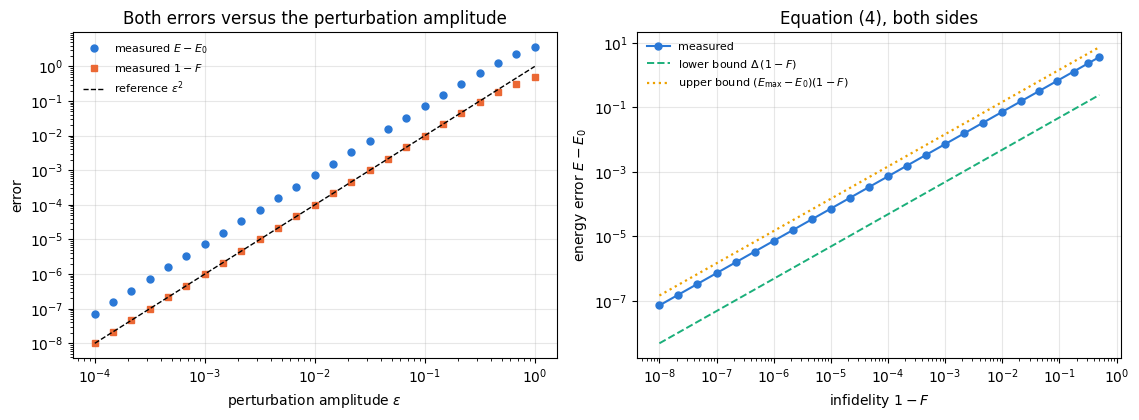


unprojected direction: |<psi_0|raw>| = 0.0362
   epsilon   (E-E0)/eps^2   (E-E0)/(1-F)
     1e-04       7.200214       7.209638
     1e-03       7.200535       7.209637
     1e-02       7.203111       7.209637
     1e-01       7.164875       7.209637


In [4]:
# ==============================================================================
# STEP 1: the energy error versus the state error, for a controlled perturbation
# ==============================================================================
N_PERT = 6
terms_pert = heisenberg_terms(N_PERT, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=1.0)      # TFIM at its critical field
H_dense = np.asarray(dense_hamiltonian(terms_pert, N_PERT))
w_pert, V_pert = np.linalg.eigh(H_dense)
E0_pert, E1_pert, Emax_pert = float(w_pert[0]), float(w_pert[1]), float(w_pert[-1])
gap_pert = E1_pert - E0_pert
psi0_pert = jnp.asarray(V_pert[:, 0], dtype=CDTYPE).reshape((2,) * N_PERT)

# a normalised direction orthogonal to the ground state: project a Haar-random state
delta = haar_state(jax.random.PRNGKey(3), N_PERT)
delta = delta - jnp.vdot(psi0_pert, delta) * psi0_pert
delta = delta / jnp.linalg.norm(delta)
print(f"TFIM N={N_PERT}, h=1: E_0 = {E0_pert:.6f}, gap Delta = {gap_pert:.6f}, E_max - E_0 = {Emax_pert - E0_pert:.6f}")
print(f"orthogonality of the perturbation direction: |<psi_0|delta>| = {float(jnp.abs(jnp.vdot(psi0_pert, delta))):.2e}")

# the constant of Eq. (2), computed from the direction alone: <delta|H|delta> - E_0
K_pert = float(energy(terms_pert, delta)) - E0_pert
print(f"<delta|H|delta> - E_0 = {K_pert:.6f}   (the predicted constant of Eq. (2))")

eps_grid = np.logspace(-4, 0, 25)
rows_pert = []
for eps in eps_grid:
    psi = (psi0_pert + eps * delta) / jnp.sqrt(1.0 + eps ** 2)
    dE = float(energy(terms_pert, psi)) - E0_pert
    inf = 1.0 - float(fidelity_pure(psi0_pert, psi))
    rows_pert.append((eps, inf, dE))
rows_pert = np.array(rows_pert)

# --- CHECKPOINT: Eq. (2) exactly, E - E_0 = (1 - F) K, and Eq. (2a) on every point ---------------------------------
dev_2 = np.max(np.abs(rows_pert[:, 2] - K_pert * rows_pert[:, 1]))
bound_2a = (Emax_pert - E0_pert) * 2 * (1 - np.sqrt(1 - rows_pert[:, 1]))
print(f"max |(E - E_0) - (1 - F) K| over the {len(eps_grid)} points = {dev_2:.1e}")
print(f"Eq. (2a): largest ratio (E - E_0) / [(E_max - E_0) * 2(1 - sqrt F)] = {np.max(rows_pert[:, 2] / bound_2a):.4f} (<= 1)")
assert dev_2 < 1e3 * TOL and np.all(rows_pert[:, 2] <= bound_2a + 1e-12)

print(f"\n{'epsilon':>10s} {'1 - F':>12s} {'E - E_0':>12s} {'lower bound':>13s} {'upper bound':>13s} {'(E-E0)/eps^2':>14s}")
for r in rows_pert[::6]:
    print(f"{r[0]:10.2e} {r[1]:12.3e} {r[2]:12.3e} {gap_pert * r[1]:13.3e} "
          f"{(Emax_pert - E0_pert) * r[1]:13.3e} {r[2] / r[0] ** 2:14.6f}")
assert np.all(rows_pert[:, 2] >= gap_pert * rows_pert[:, 1] - 1e-12)
assert np.all(rows_pert[:, 2] <= (Emax_pert - E0_pert) * rows_pert[:, 1] + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].loglog(rows_pert[:, 0], rows_pert[:, 2], MARKERS[0], ms=5, color=PALETTE[0], label=r"measured $E-E_0$")
axes[0].loglog(rows_pert[:, 0], rows_pert[:, 1], MARKERS[1], ms=4, color=PALETTE[1], label=r"measured $1-F$")
axes[0].loglog(rows_pert[:, 0], rows_pert[:, 0] ** 2, "k--", lw=1, label=r"reference $\varepsilon^2$")
axes[0].set_xlabel(r"perturbation amplitude $\varepsilon$"); axes[0].set_ylabel("error")
axes[0].set_title("Both errors versus the perturbation amplitude"); axes[0].legend(fontsize=8)

axes[1].loglog(rows_pert[:, 1], rows_pert[:, 2], MARKERS[0] + "-", ms=5, color=PALETTE[0], label=r"measured")
axes[1].loglog(rows_pert[:, 1], gap_pert * rows_pert[:, 1], "--", color=PALETTE[2], lw=1.4,
               label=r"lower bound $\Delta\,(1-F)$")
axes[1].loglog(rows_pert[:, 1], (Emax_pert - E0_pert) * rows_pert[:, 1], ":", color=PALETTE[3], lw=1.6,
               label=r"upper bound $(E_{\max}-E_0)(1-F)$")
axes[1].set_xlabel(r"infidelity $1-F$"); axes[1].set_ylabel(r"energy error $E-E_0$")
axes[1].set_title("Equation (4), both sides"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

# --- control: the SAME Haar direction without the projection (it has a component along psi_0) ------------------
raw = haar_state(jax.random.PRNGKey(3), N_PERT)
print(f"\nunprojected direction: |<psi_0|raw>| = {float(jnp.abs(jnp.vdot(psi0_pert, raw))):.4f}")
print(f"{'epsilon':>10s} {'(E-E0)/eps^2':>14s} {'(E-E0)/(1-F)':>14s}")
for eps in (1e-4, 1e-3, 1e-2, 1e-1):
    psi = psi0_pert + eps * raw
    psi = psi / jnp.linalg.norm(psi)
    dE = float(energy(terms_pert, psi)) - E0_pert
    print(f"{eps:10.0e} {dE / eps ** 2:14.6f} {dE / (1.0 - float(fidelity_pure(psi0_pert, psi))):14.6f}")

The measurement reproduces both derivations exactly.

**Equation (2).** The last column is $(E-E_0)/\varepsilon^2$. Equation (2) predicts
$K/(1+\varepsilon^2)$ with $K=\langle\delta\vert H\vert\delta\rangle-E_0=7.2096$, computed above from the direction
alone: $7.2096$ at $\varepsilon=10^{-4}$ and $10^{-3}$, $7.2089$ at $10^{-2}$, $7.1383$ at $10^{-1}$ and
$3.6048=K/2$ at $\varepsilon=1$. The infidelity is $1-F=\varepsilon^2/(1+\varepsilon^2)$, from $10^{-8}$ to $0.5$, so
the relation $E-E_0=K\,(1-F)$ holds at every point; the checkpoint confirms it to round-off over all 25 points.
Equation (2a) holds as well, with the largest ratio to its right-hand side printed above.

**The practical consequence.** At $\varepsilon=10^{-2}$ the state has infidelity $10^{-4}$ and the energy error is
$7.2\cdot10^{-4}$ out of a total energy of $-7.296$, a *relative* energy error of $10^{-4}$, while the amplitudes
are wrong at the $1\%$ level. An energy correct to four digits says nothing about the state having four correct digits.

**Equation (4).** The right panel shows the measured relation $E-E_0=7.2096\,(1-F)$ as a straight line of slope one,
lying between the two bounds at every point: the lower bound $\Delta(1-F)=0.482\,(1-F)$ and the upper bound
$(E_{\max}-E_0)(1-F)=14.59\,(1-F)$. The two bounds differ by a factor $(E_{\max}-E_0)/\Delta=30$ here, which is the
width of the window that a measured energy error leaves for the infidelity. A gapless system would make that window
infinite; Section 11 measures one.

> **Numerical practice.** The perturbation direction was built by projecting a Haar-random state onto the orthogonal
> complement of $\vert\psi_0\rangle$ (residual overlap $2.5\cdot10^{-17}$), so that $\varepsilon$ is exactly the
> amplitude of Eq. (2) and $K$ is known in advance. The projection is a convenience; the quadratic law does not
> depend on it. The control run with the unprojected direction (overlap $0.036$ with $\vert\psi_0\rangle$) still
> gives $(E-E_0)/\varepsilon^2\approx7.20$ at small $\varepsilon$, and $(E-E_0)/(1-F)=7.2096=K$ exactly, as Eq. (2a)
> requires: a component along $\vert\psi_0\rangle$ only changes the normalisation, and the orthogonal part is the
> same direction $\vert\delta\rangle$ as before. Only the relation between $\varepsilon$ and the amplitude of the
> orthogonal part changes.

## 4. The Hamiltonians

### 4.1 The Pauli convention, and what the signs mean

Throughout these notes a spin chain is written with **Pauli matrices**, not spin-$1/2$ operators
$S^a=\tfrac12\sigma^a$:

$$H=\sum_{\langle ij\rangle}\bigl(J_{xx}X_iX_j+J_{yy}Y_iY_j+J_{zz}Z_iZ_j\bigr)+h_x\sum_iX_i , \tag{6}$$

with $\langle ij\rangle$ the bonds of an open chain, $j=i+1$. The three models of this notebook are

| model | $J_{xx}$ | $J_{yy}$ | $J_{zz}$ | $h_x$ |
|---|---|---|---|---|
| XXZ | $-1$ | $-1$ | $-1/2$ | $1$ |
| XY | $-1$ | $-1$ | $0$ | $1$ |
| TFIM | $0$ | $0$ | $-1$ | $1$ |

The signs are worth one sentence each, because they are the commonest source of confusion in this subject.
A bond term $J_{xx}X_iX_j$ contributes $J_{xx}\langle X_iX_j\rangle$ to the energy. With $J_{xx}=-1$ the energy is
*lowered* by $\langle X_iX_j\rangle=+1$, i.e. by neighbouring spins **aligned** along $x$: the coupling is
**ferromagnetic** in $x$. Likewise $J_{zz}=-1$ in the TFIM is a ferromagnetic Ising coupling along $z$. A positive
$J$ would be antiferromagnetic. The field term $h_x\sum_iX_i$ with $h_x=+1$ is minimised by $\langle X_i\rangle=-1$,
i.e. every spin pointing along $-x$; for the TFIM, where the coupling acts along $z$, that field competes with the
Ising order and drives the quantum phase transition at $\lvert h_x\rvert=\lvert J_{zz}\rvert$. Section 4.3 checks
these statements against the measured correlators instead of trusting them.

### 4.2 From formula to code: traced coefficients

`heisenberg_terms` builds the list $[(\text{qubits},h_k)]$ from Python floats. We need something slightly more
flexible: the *same compiled program* must serve three different models (Section 8) and a whole field sweep
(Section 11). The fix is to build the local matrices from a **traced** coefficient vector
$\mathbf c=(J_{xx},J_{yy},J_{zz},h_x)$, so that JAX treats the couplings as data rather than as constants. The bond
matrix is then $c_0\,XX+c_1\,YY+c_2\,ZZ$, a $4\times4$ array, and the field matrix is $c_3X$.

Everything downstream (`apply_hamiltonian`, `energy`) is einsum-based and does not care whether the small matrices are
constants or traced values.

In [5]:
# ==============================================================================
# STEP 2: the model Hamiltonians, with traced coefficients
# ==============================================================================
MODELS = {"XXZ": (-1.0, -1.0, -0.5, 1.0),        # (Jxx, Jyy, Jzz, hx), Eq. (6)
          "XY": (-1.0, -1.0, 0.0, 1.0),
          "TFIM": (0.0, 0.0, -1.0, 1.0)}
MODEL_NAMES = list(MODELS)
N_SITES = 6                                       # the chain length of Sections 4-12


def model_terms(N, c):
    """Hamiltonian of Eq. (6) as a list of local terms, with c = (Jxx, Jyy, Jzz, hx) possibly TRACED.

    MATH   H = sum_{i} (c0 X_i X_{i+1} + c1 Y_i Y_{i+1} + c2 Z_i Z_{i+1}) + c3 sum_i X_i
    IMPL   one 4x4 bond matrix (identical on every bond) and one 2x2 field matrix; the qubit indices are
           static Python ints, the matrix ENTRIES may be traced -> one compilation serves every coupling.
    """
    bond = c[0] * XX + c[1] * YY + c[2] * ZZ
    field = c[3] * X
    return [((i, i + 1), bond) for i in range(N - 1)] + [((i,), field) for i in range(N)]


# --- CHECKPOINT: the traced construction reproduces the engine's, and Lanczos reproduces dense eigh ------
print(f"{'model':>6s} {'E_0 (Lanczos)':>15s} {'E_0 (dense eigh)':>17s} {'difference':>12s} "
      f"{'gap':>9s} {'E_max - E_0':>12s} {'terms vs engine':>16s}")
EXACT = {}
for name in MODEL_NAMES:
    c = jnp.asarray(MODELS[name], dtype=RDTYPE)
    terms = model_terms(N_SITES, c)
    terms_engine = heisenberg_terms(N_SITES, Jxx=MODELS[name][0], Jyy=MODELS[name][1],
                                    Jzz=MODELS[name][2], hx=MODELS[name][3])
    d_terms = max(max_abs(a[1] - b[1]) for a, b in zip(terms, terms_engine))
    w, V = np.linalg.eigh(np.asarray(dense_hamiltonian(terms, N_SITES)))
    E0_l, psi0_l = lanczos_ground_state(terms, N_SITES)
    psi0_l = psi0_l / jnp.linalg.norm(psi0_l)
    EXACT[name] = dict(E0=float(w[0]), E1=float(w[1]), Emax=float(w[-1]), psi0=psi0_l,
                       psi1=jnp.asarray(V[:, 1], dtype=CDTYPE).reshape((2,) * N_SITES))
    print(f"{name:>6s} {E0_l:15.9f} {float(w[0]):17.9f} {abs(E0_l - float(w[0])):12.2e} "
          f"{float(w[1] - w[0]):9.4f} {float(w[-1] - w[0]):12.4f} {d_terms:16.1e}")
    assert abs(E0_l - float(w[0])) < 1e-8 and d_terms < TOL
    assert abs(float(fidelity_pure(psi0_l, jnp.asarray(V[:, 0], dtype=CDTYPE).reshape((2,) * N_SITES))) - 1) < 1e-8

 model   E_0 (Lanczos)  E_0 (dense eigh)   difference       gap  E_max - E_0  terms vs engine


   XXZ   -11.192715190     -11.192715190     7.11e-15    2.7595      19.8470          0.0e+00
    XY   -11.706936695     -11.706936695     1.07e-14    3.3503      19.2074          0.0e+00


  TFIM    -7.296229811      -7.296229811     7.99e-15    0.4821      14.5925          0.0e+00


### 4.3 What the exact ground states look like

Before optimising anything we measure the nine quantities that Section 8 will track, on the *exact* ground states.
They are the targets, and they also settle the sign question of Section 4.1: a ferromagnetic $x$ coupling must show
$\langle X_iX_{i+1}\rangle>0$.

The nine are the half-chain entanglement entropy

$$S_{\mathrm{half}}=-\mathrm{Tr}\,\rho_A\log_2\rho_A,\qquad A=\{0,\dots,N/2-1\},$$

the three mean magnetisations $\langle X\rangle=\frac1N\sum_q\langle X_q\rangle$ (and likewise $Y$, $Z$), the three
mean nearest-neighbour correlators $\langle XX\rangle=\frac1{N-1}\sum_q\langle X_qX_{q+1}\rangle$ (and likewise), and
the energy and the fidelity, which are trivial on the exact state.

In [6]:
# ==============================================================================
# STEP 3: the nine tracked observables, as one jit-able function of the state
# ==============================================================================
METRIC_KEYS = ["E - E_0", "S_half", "F", "<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"]   # for printed tables
METRIC_TEX = [r"$E-E_0$", r"$S_{\rm half}$ [bits]", r"$F$", r"$\langle X\rangle$", r"$\langle Y\rangle$",
              r"$\langle Z\rangle$", r"$\langle XX\rangle$", r"$\langle YY\rangle$", r"$\langle ZZ\rangle$"]


def state_observables(psi):
    """(S_half, <X>, <Y>, <Z>, <XX>, <YY>, <ZZ>) of a state tensor -- seven of the nine tracked numbers.

    MATH   S_half = entanglement entropy of the first N/2 qubits (base 2)
           <X> = (1/N) sum_q <X_q>              (and the same for Y, Z)
           <XX> = (1/(N-1)) sum_q <X_q X_{q+1}> (and the same for YY, ZZ)
    IMPL   `all_local_expectations` returns the (N,3) array of Bloch vectors from the N single-qubit RDMs;
           each bond correlator is one `expect_pauli_string`, i.e. two einsums and an inner product.
    COST   O(N 2^N).
    """
    N = psi.ndim
    S = entanglement_entropy(psi, range(N // 2))
    loc = all_local_expectations(psi)                                   # (N, 3): <X_q>, <Y_q>, <Z_q>
    corr = [jnp.mean(jnp.stack([expect_pauli_string(psi, {q: p, q + 1: p}) for q in range(N - 1)]))
            for p in ("X", "Y", "Z")]
    return jnp.stack([S, loc[:, 0].mean(), loc[:, 1].mean(), loc[:, 2].mean()] + corr)


def parity(psi):
    """<P> with P = prod_q X_q, the Z_2 symmetry operator of Eq. (7)."""
    return expect_pauli_string(psi, "X" * psi.ndim)


print(f"{'model':>6s} {'E_0':>10s} {'S_half':>8s} {'<X>':>8s} {'<Y>':>8s} {'<Z>':>8s} "
      f"{'<XX>':>8s} {'<YY>':>8s} {'<ZZ>':>8s} {'parity':>8s}")
for name in MODEL_NAMES:
    o = np.asarray(state_observables(EXACT[name]["psi0"]))
    EXACT[name]["obs"] = o
    print(f"{name:>6s} {EXACT[name]['E0']:10.5f} {o[0]:8.4f} {o[1]:+8.4f} {o[2]:+8.4f} {o[3]:+8.4f} "
          f"{o[4]:+8.4f} {o[5]:+8.4f} {o[6]:+8.4f} {float(parity(EXACT[name]['psi0'])):+8.4f}")

 model        E_0   S_half      <X>      <Y>      <Z>     <XX>     <YY>     <ZZ>   parity


   XXZ  -11.19272   0.0498  -0.9787  +0.0000  +0.0000  +0.9798  +0.1577  -0.1468  +1.0000
    XY  -11.70694   0.1248  -0.9324  +0.0000  +0.0000  +0.9403  +0.2822  -0.2607  +1.0000
  TFIM   -7.29623   0.4732  -0.7711  -0.0000  +0.0000  +0.7398  -0.3212  +0.5339  +1.0000


Lanczos and dense diagonalisation agree to $10^{-14}$ in all three models, and the traced term list is bit-identical
to the engine's. The physics in the table is worth reading carefully, because it decides what the rest of the
notebook is about.

**The signs mean what Section 4.1 said.** For the XXZ chain $\langle X_iX_{i+1}\rangle=+0.980$: neighbouring spins
are *aligned* along $x$. A coupling $J_{xx}=-1$ is ferromagnetic in the Pauli convention, and reading "$J<0$" as
"antiferromagnetic" — a habit carried over from Hamiltonians written with an explicit minus sign in front of the sum
— would have been wrong by a sign here.

**The XXZ and XY chains at these couplings are nearly polarised product states.** $\langle X_q\rangle=-0.979$ and
$-0.932$ respectively: the transverse field $h_x=+1$ has aligned every spin along $-x$, and the ferromagnetic $xx$
coupling agrees with it. The half-chain entanglement is $0.050$ and $0.125$ bits, so these two states are barely
entangled at all, and their gaps, $2.76$ and $3.35$, are large. They are *easy* targets, and the results of
Section 8 should be read with that in mind.

**The Ising chain at $h_x=1$ is the interesting one.** Its field equals its coupling in magnitude, which is the
critical point of the model: the entanglement is $0.473$ bits, an order of magnitude above the other two, and the
gap $0.482$ is smaller by a factor of six. Everything hard in this notebook happens there.

**$\langle Y\rangle$ and $\langle Z\rangle$ vanish identically, and that is the symmetry.** If
$P\vert\psi\rangle=\pm\vert\psi\rangle$ with $P=\prod_qX_q$, then for any operator $A$,
$\langle A\rangle=\langle\psi\vert P A P\vert\psi\rangle$. Since $X_qY_qX_q=-Y_q$ and the $X$ factors on the other
qubits commute through, $PY_qP=-Y_q$ and likewise $PZ_qP=-Z_q$, so $\langle Y_q\rangle=-\langle Y_q\rangle=0$ and
$\langle Z_q\rangle=0$. A *pair* $Y_iY_j$ picks up two signs and survives, which is why $\langle YY\rangle$ and
$\langle ZZ\rangle$ are non-zero. The printed parity is $+1$ for all three ground states. Section 5 proves
$[H,P]=0$; the table already shows its fingerprints.

**A measured coupling effect.** The only difference between XXZ and XY is $J_{zz}$: $-1/2$ against $0$. The
ferromagnetic $zz$ coupling pulls $\langle ZZ\rangle$ from $-0.261$ (XY) up to $-0.147$ (XXZ), as a ferromagnetic
term should, without managing to make it positive against the dominant $x$ polarisation.

## 5. Symmetry: what the Hamiltonian has and the ansatz has not

### 5.1 The $\mathbb Z_2$ parity of Eq. (6)

Define the **parity operator**

$$P=\prod_{q=0}^{N-1}X_q ,\qquad P^2=\mathbb 1,\qquad \text{eigenvalues }\pm1 . \tag{7}$$

Does it commute with $H$? Check term by term, using that two Pauli operators on the same qubit either commute (equal
operators) or anticommute (different operators), and that operators on different qubits always commute.

* $h_xX_i$: $P$ contains $X_i$, which commutes with $X_i$; all other factors act on other qubits. Commutes.
* $J_{xx}X_iX_j$: same argument twice. Commutes.
* $J_{yy}Y_iY_j$: $P$ contains $X_i$ and $X_j$, each of which *anticommutes* with the $Y$ on its own qubit. Two sign
  flips multiply to $+1$. Commutes.
* $J_{zz}Z_iZ_j$: identical argument with $Z$. Commutes.

So $[H,P]=0$ for all three models. The eigenvectors of $H$ can be labelled by $P=\pm1$, and the ground state has a
definite parity. (A term with an *odd* number of $Y$ or $Z$ operators, for instance a longitudinal field $h_zZ_i$,
would break it — which is exactly how one destroys the symmetry in a simulation.)

### 5.2 The $U(1)$ symmetry that the transverse field destroys

The XXZ chain is famous for conserving the total magnetisation $S^z_{\text{tot}}=\sum_qZ_q$, which follows from
$[X_iX_j+Y_iY_j,\,Z_i+Z_j]=0$: the $XX+YY$ term only moves a spin flip from one site to the next. That conservation
law is the reason the XXZ chain can be diagonalised block by block. **It does not survive the transverse field.**
$[X_i,Z_i]=-2iY_i\neq0$, so the $h_x\sum_iX_i$ term of Eq. (6) does not commute with $S^z_{\text{tot}}$, and with
$h_x=1$ there is no $U(1)$ symmetry to protect. The numbers below verify both statements matrix-free: we apply the
commutator to a random state and measure its norm,

$$\lVert[H,A]\,\vert\phi\rangle\rVert=\bigl\lVert H(A\vert\phi\rangle)-A(H\vert\phi\rangle)\bigr\rVert ,$$

which needs no $2^N\times2^N$ matrix at all.

### 5.3 The ansatz does not know about any of this

The hardware-efficient ansatz of
[40 — parametrized gates](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb) starts from
$\vert0\rangle^{\otimes N}$ and applies $R_y,R_z$ rotations and $CZ$ gates. The starting state is not an eigenstate of
$P$ ($P\vert0\cdots0\rangle=\vert1\cdots1\rangle$), and $R_y(\theta)$ does not commute with $X$, so
$\vert\psi(\boldsymbol\theta)\rangle$ has no definite parity for generic angles.

![Hardware-efficient ansatz on six qubits: Ry and Rz on every qubit, a chain of CZ gates, repeated L times, then a final rotation block](figures/hea_ansatz.svg)\
**Figure 1.** The ansatz of Sections 5 to 8 on the $N=6$ chain of this notebook. Each dashed layer applies $R_y$ and
then $R_z$, each with its own angle, on every qubit, followed by $CZ$ on the bonds $(0,1),\dots,(4,5)$ in that order;
a final rotation block closes the circuit. With $L=4$ layers there are $2N(L+1)=60$ angles. Section 10 varies $L$,
and Section 9.2 compares it with the Hamiltonian-variational ansatz.

We call

$$\text{symmetry leakage}\;=\;1-\lvert\langle P\rangle\rvert\;\in[0,1] \tag{8}$$

the amount by which the variational state fails to be a parity eigenstate; it is $0$ for an eigenstate of $P$ and
$1$ for a state with $\langle P\rangle=0$, such as a random one. A symmetry-preserving ansatz would fix the leakage at
zero by construction and search a smaller space; the hardware-efficient family must instead *learn* the symmetry, and
whether it does is an empirical question answered in Section 9.

In [7]:
# ==============================================================================
# STEP 4: commutators, matrix-free, and the parity of random ansatz states
# ==============================================================================
def commutator_norm(terms, op_fn, psi):
    """|| [H, A] |psi> || with A applied by `op_fn` -- two Hamiltonian applications, no big matrix."""
    return float(jnp.linalg.norm(apply_hamiltonian(terms, op_fn(psi)) - op_fn(apply_hamiltonian(terms, psi))))


def apply_parity(psi):
    """P|psi> with P = prod_q X_q."""
    return apply_pauli_string(psi, "X" * psi.ndim)


def apply_sz_total(psi):
    """S^z_tot |psi> = sum_q Z_q |psi>  (a sum of N single-qubit einsums)."""
    return sum(apply_gate(psi, Z, [q]) for q in range(psi.ndim))


phi_rand = haar_state(jax.random.PRNGKey(11), N_SITES)
print(f"{'model':>6s} {'|| [H,P] phi ||':>16s} {'|| [H,S^z] phi ||':>18s}   (phi = Haar random, norm 1)")
for name in MODEL_NAMES:
    terms = model_terms(N_SITES, jnp.asarray(MODELS[name], dtype=RDTYPE))
    cp = commutator_norm(terms, apply_parity, phi_rand)
    cz = commutator_norm(terms, apply_sz_total, phi_rand)
    print(f"{name:>6s} {cp:16.2e} {cz:18.4f}")
    assert cp < 1e3 * TOL

# the same XXZ model WITHOUT the transverse field does conserve S^z
terms_nofield = model_terms(N_SITES, jnp.asarray((-1.0, -1.0, -0.5, 0.0), dtype=RDTYPE))
print(f"{'XXZ, h_x=0':>12s} {commutator_norm(terms_nofield, apply_parity, phi_rand):10.2e} "
      f"{commutator_norm(terms_nofield, apply_sz_total, phi_rand):18.2e}")
assert commutator_norm(terms_nofield, apply_sz_total, phi_rand) < 1e3 * TOL

# parity of ansatz states at random angles
L_MAIN = 4
n_main = hea_num_params(N_SITES, L_MAIN)
th_rand, _ = random_starts(200, n_main, seed=12)
par_rand = np.asarray(jax.jit(jax.vmap(lambda t: parity(hardware_efficient_ansatz(t, N_SITES, L_MAIN))))(th_rand))
print(f"\nhardware-efficient ansatz, N={N_SITES}, L={L_MAIN}, n={n_main} angles, 200 random parameter vectors:")
print(f"  <P>: mean {par_rand.mean():+.4f}, standard deviation {par_rand.std():.4f}, "
      f"largest |<P>| {np.abs(par_rand).max():.4f}")
print(f"  median symmetry leakage 1 - |<P>| = {np.median(1 - np.abs(par_rand)):.4f}")

 model  || [H,P] phi ||  || [H,S^z] phi ||   (phi = Haar random, norm 1)
   XXZ         0.00e+00             4.4114
    XY         0.00e+00             4.4114
  TFIM         0.00e+00             4.4114
  XXZ, h_x=0   0.00e+00           8.50e-16



hardware-efficient ansatz, N=6, L=4, n=60 angles, 200 random parameter vectors:
  <P>: mean -0.0042, standard deviation 0.0994, largest |<P>| 0.2784
  median symmetry leakage 1 - |<P>| = 0.9403


The commutator with the parity operator is **exactly zero** in floating point. $P$ only permutes the amplitudes
(it flips every bit of the index), and each local term maps the permuted array to the permutation of its own output
with the same arithmetic on the same numbers, so the two orders of application agree bit for bit. The commutator with
$S^z_{\text{tot}}$ is $4.41$ for all three models, and the fact that it is the *same* number three times is itself
informative: the $XX+YY$ and $ZZ$ bond terms all commute with $S^z_{\text{tot}}$, so the entire commutator comes from
the field, $[H,S^z_{\text{tot}}]=h_x[\sum_iX_i,\sum_qZ_q]$, which does not depend on the couplings at all. Switching
the field off restores the conservation law to machine precision ($8.5\cdot10^{-16}$), confirming that the transverse
field, and nothing else, is what destroys the $U(1)$ symmetry of the XXZ chain.

The ansatz has no such structure. Over 200 random parameter vectors the parity of the hardware-efficient state
is centred on zero with a standard deviation of $0.099$ and never exceeds $0.28$ in magnitude; the median symmetry
leakage of Eq. (8) is $0.94$. Since $\langle P\rangle=w_+-w_-$ with $w_\pm$ the weights in the two sectors,
the optimiser starts in a state with nearly equal weight in both sectors, and half of the Hilbert space it explores
is orthogonal to the answer.

> **Physics insight.** A symmetry of $H$ block-diagonalises it. Working inside one block is both cheaper (half the
> dimension) and safer (the answer cannot leak into the wrong sector). An ansatz that respects the symmetry gets
> that for free; a hardware-efficient ansatz has to spend parameters on rediscovering it. Section 9 measures how
> well it succeeds, and builds an ansatz that cannot fail.

## 6. The VQE loop

Everything is now in place. The algorithm is four lines of mathematics:

1. choose an ansatz $\vert\psi(\boldsymbol\theta)\rangle=U(\boldsymbol\theta)\vert0\rangle^{\otimes N}$ and a random
   starting point $\boldsymbol\theta^{(0)}$;
2. evaluate $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle$ and its
   gradient (here by reverse-mode automatic differentiation; on hardware by the parameter-shift rule of notebook 40);
3. update $\boldsymbol\theta$ with Adam;
4. repeat, and *restart from many random initialisations*, because the landscape has many minima.

The only implementation subtlety is the diagnostic. The optimiser minimises the energy, but we want to watch nine
physical quantities. `train` records whatever `monitor` returns, and `lax.scan` is happy to stack a **vector**, so one
compiled program produces an array of shape (runs, iterations, 9) at essentially the cost of the training itself.

> **JAX practice.** The Hamiltonian coefficients, the reference energy and the reference state enter `vqe_metrics` as
> ordinary arguments. Mapping `vmap` over them therefore lets us train on all three models in **one**
> compilation instead of three: the circuit graph is identical, only the numbers differ. Compilation dominates the
> wall time of short variational runs (Section 8 times the two separately: about $4$ s of compilation against
> $2$ s of execution for $3\times12\times300$ iterations), so this is worth more than any micro-optimisation inside the
> loop.

In [8]:
# ==============================================================================
# STEP 5: the cost, the nine-component monitor, and one batched run over models
# ==============================================================================
def ansatz_state(theta, N=N_SITES, layers=L_MAIN):
    """The hardware-efficient ansatz as a pure function theta -> state tensor."""
    return hardware_efficient_ansatz(theta, N, layers)


def vqe_cost(theta, c, N=N_SITES, layers=L_MAIN):
    """C(theta) = <psi(theta)| H(c) |psi(theta)>, the VQE objective."""
    return energy(model_terms(N, c), ansatz_state(theta, N, layers))


def vqe_metrics(theta, c, psi_ref, E_ref, N=N_SITES, layers=L_MAIN):
    """The nine tracked numbers of Section 4.3 for the current angles, as one stacked vector.

    Order: (E - E_ref, S_half, F, <X>, <Y>, <Z>, <XX>, <YY>, <ZZ>)  -- METRIC_KEYS.
    """
    psi = ansatz_state(theta, N, layers)
    E = energy(model_terms(N, c), psi)
    F = fidelity_pure(psi_ref, psi)
    obs = state_observables(psi)
    return jnp.concatenate([jnp.stack([E - E_ref, obs[0], F]), obs[1:]])


def vqe_run(c, psi_ref, E_ref, thetas, keys, lr, n_steps, N=N_SITES, layers=L_MAIN):
    """Train `thetas.shape[0]` independent restarts on the Hamiltonian H(c).

    Returns (final angles of every restart, histories of shape (runs, steps, 9)).
    """
    cost = lambda t: vqe_cost(t, c, N, layers)
    monitor = lambda t: vqe_metrics(t, c, psi_ref, E_ref, N, layers)
    return jax.vmap(lambda t, k: train(t, k, grad_exact(cost), opt_adam(lr), monitor, n_steps))(thetas, keys)

## 7. Choosing the step size by measurement

Notebook 41 measured that Adam's best learning rate on an *energy* landscape is not the one that works on an
infidelity landscape, and that every optimiser's result varies over orders of magnitude across the grid. We therefore
tune here too, on the hardest of the three models (the critical Ising chain), with a short run. The learning rate is
passed as a **traced** scalar so that the whole sweep is one compilation.

In [9]:
# ==============================================================================
# STEP 6: learning-rate sweep, nested vmap (learning rate x restart)
# ==============================================================================
LR_GRID = jnp.asarray([0.05, 0.1, 0.2, 0.4, 0.8], dtype=RDTYPE)
R_TUNE, T_TUNE = 6, 200
th_tune, ks_tune = random_starts(R_TUNE, n_main, seed=21)
c_tfim = jnp.asarray(MODELS["TFIM"], dtype=RDTYPE)
E0_tfim, psi0_tfim = EXACT["TFIM"]["E0"], EXACT["TFIM"]["psi0"]

t0 = time.perf_counter()
sweep = jax.jit(jax.vmap(lambda lr: jax.vmap(
    lambda t, k: train(t, k, grad_exact(lambda z: vqe_cost(z, c_tfim)),
                       opt_adam(lr), lambda z: vqe_cost(z, c_tfim) - E0_tfim, T_TUNE)[1])(th_tune, ks_tune)))
H_tune = np.asarray(jax.block_until_ready(sweep(LR_GRID)))       # (n_lr, n_runs, n_steps)
print(f"learning-rate sweep: {len(LR_GRID)} rates x {R_TUNE} restarts x {T_TUNE} iterations "
      f"in {time.perf_counter() - t0:.1f} s (one compilation)")
print(f"\n{'learning rate':>14s} {'median final E - E_0':>22s} {'best final':>13s}")
med_tune = np.median(H_tune[:, :, -1], axis=1)
for j, lr in enumerate(np.asarray(LR_GRID)):
    print(f"{lr:14.3g} {med_tune[j]:22.5f} {H_tune[j, :, -1].min():13.5f}")
LR_BEST = float(np.asarray(LR_GRID)[int(np.argmin(med_tune))])
print(f"\nbest learning rate on this landscape: {LR_BEST:g}")

learning-rate sweep: 5 rates x 6 restarts x 200 iterations in 4.5 s (one compilation)

 learning rate   median final E - E_0    best final
          0.05                0.15524       0.12860
           0.1                0.11591       0.01847
           0.2                0.03116       0.00942
           0.4                0.01915       0.00561
           0.8                0.03792       0.00795

best learning rate on this landscape: 0.4


The median final energy error varies by a factor of eight across the grid — $0.155$ at $\eta=0.05$, $0.019$ at
$\eta=0.4$, back up to $0.038$ at $\eta=0.8$ — with the smallest median at $\eta=0.4$. With six restarts per rate the
neighbours $0.2$ and $0.8$ are not cleanly separated from it (their medians are within a factor of two), so the grid
fixes the order of magnitude of the step rather than its exact value. That is close to the $0.45$ that notebook 41
measured for Adam on the energy landscape of an antiferromagnetic Ising chain ($N=6$, $h=0.8$, $L=3$), and far from the
$0.13$ that the same notebook found best on an *infidelity* landscape. Adam's update
$\eta\,\hat m/(\sqrt{\hat v}+\epsilon)$ is unchanged when the cost is multiplied by a constant, so $\eta$ is a step
length in angle space, and its best value is set by the angular width of the valleys of the particular landscape;
those widths differ between cost functions, so step sizes do not transfer. All the hardware-efficient runs below use
$\eta=0.4$.

## 8. VQE for the three models: nine metrics against the exact ground state

The main experiment. For each of the three Hamiltonians we train twelve independent random restarts for 300 Adam
iterations with exact gradients, and record all nine observables at every iteration. The figure shows the **median**
over restarts as a line and the **interquartile range** as a band; the dashed horizontal line in each panel is the
exact value computed in Section 4.3. A single training curve would say nothing — notebook 41 measured final results
spanning ten orders of magnitude across restarts of one configuration.

In [10]:
# ==============================================================================
# STEP 7: train all three models in one compiled, batched program
# ==============================================================================
R_MAIN, T_MAIN = 12, 300
th_main, ks_main = random_starts(R_MAIN, n_main, seed=31)
C_STACK = jnp.stack([jnp.asarray(MODELS[k], dtype=RDTYPE) for k in MODEL_NAMES])
PSI_STACK = jnp.stack([EXACT[k]["psi0"] for k in MODEL_NAMES])
E0_STACK = jnp.asarray([EXACT[k]["E0"] for k in MODEL_NAMES], dtype=RDTYPE)

run_all = jax.jit(jax.vmap(lambda c, p, e: vqe_run(c, p, e, th_main, ks_main, LR_BEST, T_MAIN)))
t0 = time.perf_counter()
run_all_compiled = run_all.lower(C_STACK, PSI_STACK, E0_STACK).compile()       # trace + XLA compilation only
t_compile = time.perf_counter() - t0
t0 = time.perf_counter()
TH_FINAL, HIST = jax.block_until_ready(run_all_compiled(C_STACK, PSI_STACK, E0_STACK))  # (3, runs, n), (3, runs, steps, 9)
t_run = time.perf_counter() - t0
HIST = np.asarray(HIST)
print(f"3 models x {R_MAIN} restarts x {T_MAIN} iterations, N={N_SITES}, L={L_MAIN}, n={n_main} angles: "
      f"compilation {t_compile:.1f} s, execution {t_run:.1f} s")

TARGET_E = 1e-2
print(f"\n{'model':>6s} {'median E-E_0':>14s} {'best E-E_0':>12s} {'median F':>10s} {'best F':>9s} "
      f"{'median S_half':>14s} {'exact S_half':>13s} {'success rate':>13s} {'median iters':>13s}")
for i, name in enumerate(MODEL_NAMES):
    h = HIST[i]
    s = summarise(name, h[:, :, 0], TARGET_E, 2 * n_main)
    print(f"{name:>6s} {np.median(h[:, -1, 0]):14.6f} {h[:, -1, 0].min():12.6f} {np.median(h[:, -1, 2]):10.4f} "
          f"{h[:, -1, 2].max():9.4f} {np.median(h[:, -1, 1]):14.4f} {EXACT[name]['obs'][0]:13.4f} "
          f"{s['success']:13.2f} {s['iters']:13.1f}")
print(f"(success = fraction of the {R_MAIN} restarts reaching E - E_0 < {TARGET_E:g}; "
      f"median iterations over the successful ones)")

# --- how significant are the differences between the models?  12 restarts each ---------------------------------
print("\n68% Wilson intervals of the success rates: " + ", ".join(
    f"{name} [{wilson_interval(int((iterations_to(HIST[i, :, :, 0], TARGET_E) > 0).sum()), R_MAIN)[0]:.2f}, "
    f"{wilson_interval(int((iterations_to(HIST[i, :, :, 0], TARGET_E) > 0).sum()), R_MAIN)[1]:.2f}]"
    for i, name in enumerate(MODEL_NAMES)))
i_xxz, i_xy, i_tf = (MODEL_NAMES.index(k) for k in ("XXZ", "XY", "TFIM"))
p_dE = perm_pvalue(HIST[i_xxz, :, -1, 0], HIST[i_tf, :, -1, 0], seed=1)
p_inf = perm_pvalue(1 - HIST[i_xy, :, -1, 2], 1 - HIST[i_tf, :, -1, 2], seed=2)
p_null = perm_pvalue(1 - HIST[i_tf, ::2, -1, 2], 1 - HIST[i_tf, 1::2, -1, 2], seed=3)
print(f"permutation p-values (medians of log values): final E - E_0, XXZ vs TFIM: {p_dE:.3f};  "
      f"final 1 - F, XY vs TFIM: {p_inf:.4f}")
print(f"control (two halves of the SAME TFIM restarts, no real difference): 1 - F p-value {p_null:.3f}")
assert p_inf < 0.01 and p_null > 0.05
for i, name in enumerate(MODEL_NAMES):
    it = iterations_to(HIST[i, :, :, 0], TARGET_E)
    print(f"{name:>6s}: iterations of the successful restarts {sorted(int(v) for v in it[it > 0])};  "
          f"restarts ending below the exact S_half: {int(np.sum(HIST[i, :, -1, 1] < EXACT[name]['obs'][0]))}/{R_MAIN}")
assert HIST[:, :, :, 0].min() > -1e-9, "variational principle violated -- check the Hamiltonian or the reference"
print("\nCHECKPOINT the variational principle held in all "
      f"{HIST.shape[0] * HIST.shape[1] * HIST.shape[2]} recorded energies: E - E_0 >= 0 "
      f"(smallest value {HIST[:, :, :, 0].min():.3e}).")

3 models x 12 restarts x 300 iterations, N=6, L=4, n=60 angles: compilation 3.6 s, execution 1.7 s

 model   median E-E_0   best E-E_0   median F    best F  median S_half  exact S_half  success rate  median iters
   XXZ       0.011549     0.002572     0.9985    0.9997         0.0428        0.0498          0.83         166.0
    XY       0.011276     0.002356     0.9984    0.9998         0.1203        0.1248          0.83         129.5
  TFIM       0.016147     0.004487     0.9946    0.9987         0.4304        0.4732          0.50         273.5
(success = fraction of the 12 restarts reaching E - E_0 < 0.01; median iterations over the successful ones)

68% Wilson intervals of the success rates: XXZ [0.70, 0.91], XY [0.70, 0.91], TFIM [0.36, 0.64]


permutation p-values (medians of log values): final E - E_0, XXZ vs TFIM: 0.423;  final 1 - F, XY vs TFIM: 0.0033
control (two halves of the SAME TFIM restarts, no real difference): 1 - F p-value 0.339
   XXZ: iterations of the successful restarts [70, 74, 132, 133, 165, 167, 188, 197, 224, 250];  restarts ending below the exact S_half: 12/12
    XY: iterations of the successful restarts [65, 66, 76, 91, 129, 130, 133, 182, 226, 252];  restarts ending below the exact S_half: 10/12
  TFIM: iterations of the successful restarts [148, 181, 257, 290, 292, 294];  restarts ending below the exact S_half: 12/12

CHECKPOINT the variational principle held in all 10800 recorded energies: E - E_0 >= 0 (smallest value 1.636e-03).


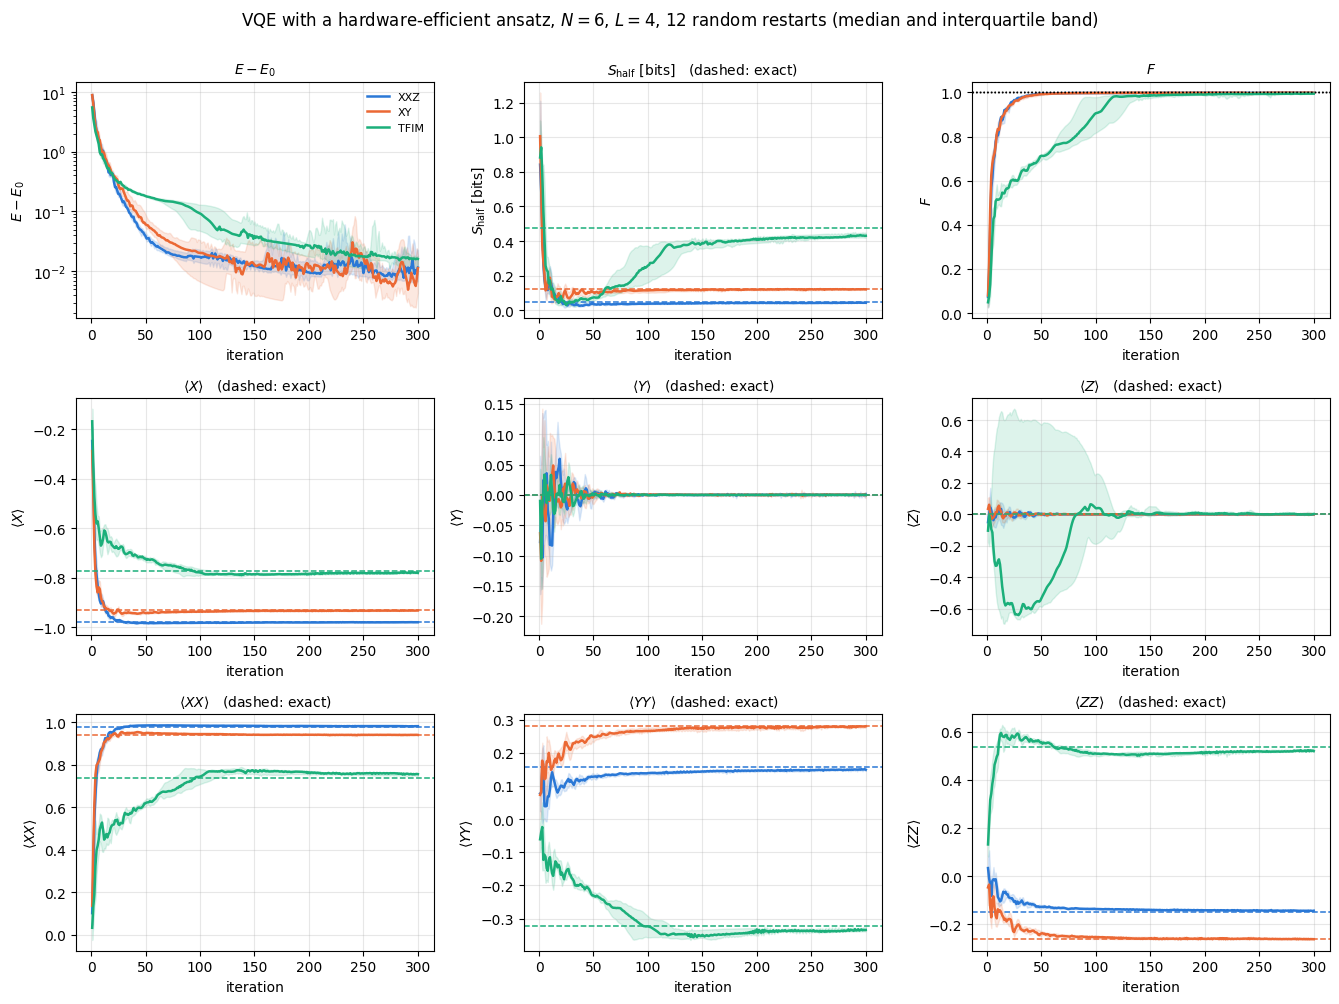

 model   observable     exact  VQE median           VQE IQR  median error
   XXZ          <X>   -0.9787     -0.9804 [-0.9808,-0.9798]       -0.0017
   XXZ          <Y>   +0.0000     +0.0008 [-0.0002,+0.0048]       +0.0008
   XXZ          <Z>   +0.0000     +0.0000 [-0.0005,+0.0021]       +0.0000
   XXZ         <XX>   +0.9798     +0.9822 [+0.9810,+0.9827]       +0.0024
   XXZ         <YY>   +0.1577     +0.1491 [+0.1453,+0.1513]       -0.0086
   XXZ         <ZZ>   -0.1468     -0.1434 [-0.1449,-0.1415]       +0.0034
    XY          <X>   -0.9324     -0.9328 [-0.9341,-0.9323]       -0.0004
    XY          <Y>   +0.0000     -0.0001 [-0.0054,+0.0003]       -0.0001
    XY          <Z>   +0.0000     -0.0005 [-0.0033,+0.0002]       -0.0005
    XY         <XX>   +0.9403     +0.9409 [+0.9401,+0.9415]       +0.0006
    XY         <YY>   +0.2822     +0.2801 [+0.2769,+0.2811]       -0.0022
    XY         <ZZ>   -0.2607     -0.2616 [-0.2631,-0.2598]       -0.0010
  TFIM          <X>   -0.7711     -0.7

In [11]:
# ==============================================================================
# STEP 8: the 3 x 3 panel of metrics -- median and interquartile band, per model
# ==============================================================================
fig, axes = plt.subplots(3, 3, figsize=(13.5, 10.0))
it_axis = np.arange(1, T_MAIN + 1)
for m, ax in enumerate(axes.ravel()):
    for i, name in enumerate(MODEL_NAMES):
        lo, med, hi = bands(HIST[i, :, :, m])
        if m == 0:
            lo, med, hi = (np.maximum(a, 1e-12) for a in (lo, med, hi))
        ax.fill_between(it_axis, lo, hi, color=PALETTE[i], alpha=0.15)
        ax.plot(it_axis, med, "-", lw=1.8, color=PALETTE[i], label=name)
        if m == 0:
            ax.set_yscale("log")
        elif m == 2:
            ax.axhline(1.0, color="k", ls=":", lw=1)
        else:
            ref = EXACT[name]["obs"][m - 2] if m >= 3 else EXACT[name]["obs"][0]
            ax.axhline(ref, color=PALETTE[i], ls="--", lw=1.1)
    ax.set_xlabel("iteration")
    ax.set_ylabel(METRIC_TEX[m])
    ax.set_title(METRIC_TEX[m] + ("" if m in (0, 2) else "   (dashed: exact)"), fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"VQE with a hardware-efficient ansatz, $N={N_SITES}$, $L={L_MAIN}$, "
             f"{R_MAIN} random restarts (median and interquartile band)", y=1.0)
fig.tight_layout(); plt.show()

print(f"{'model':>6s} {'observable':>12s} {'exact':>9s} {'VQE median':>11s} {'VQE IQR':>17s} {'median error':>13s}")
for i, name in enumerate(MODEL_NAMES):
    for m in range(3, 9):
        vals = HIST[i, :, -1, m]
        ref = EXACT[name]["obs"][m - 2]
        print(f"{name:>6s} {METRIC_KEYS[m]:>12s} {ref:+9.4f} {np.median(vals):+11.4f} "
              f"[{np.percentile(vals, 25):+.4f},{np.percentile(vals, 75):+.4f}] {np.median(vals) - ref:+13.4f}")

**The variational principle is a free unit test, and it passed.** Across $3\times12\times300=10800$ recorded
energies the error $E-E_0$ never went negative; its smallest value over the whole experiment was
$1.6\cdot10^{-3}$. Had the term list, the ansatz convention or the Lanczos reference been inconsistent, this is
where it would have shown.

**The energies converge and the states nearly do.** The median final energy error is $0.0115$ (XXZ), $0.0113$ (XY)
and $0.0161$ (TFIM), a relative error of $1$ to $2\cdot10^{-3}$; the median fidelities are $0.9985$, $0.9984$ and
$0.9946$. Twelve restarts per model are enough to separate some of these numbers and not others, and the
permutation tests printed above say which. The **energy errors** of the three models are statistically
indistinguishable (XXZ against TFIM: $p=0.42$), and so are the success rates: $10/12$ against $6/12$ reach
$E-E_0<10^{-2}$, with 68% intervals $[0.70,0.91]$ and $[0.36,0.64]$ that nearly touch (a Fisher exact test gives
$p=0.19$). The **infidelities** do differ: the Ising chain is further from its ground state than the XY chain
($p=0.003$), while the control comparison of two halves of the *same* Ising runs shows no difference ($p=0.34$), as it
must. That is the expected ordering by gap: by Eq. (5)
a similar energy error certifies $1-F\le(E-E_0)/\Delta$, and the Ising gap is six times smaller. The successful Ising
runs also arrive later (median $274$ iterations against $166$ and $130$), but three of its six successes cross the
threshold within the last ten iterations of the budget, so this number mostly says that the budget was just long
enough.

**The entanglement ends below the exact value.** The median $S_{\mathrm{half}}$ is $0.043$ against an exact
$0.050$, $0.120$ against $0.125$, and $0.430$ against $0.473$. Restart by restart, all twelve XXZ and all twelve
Ising states end below the exact entropy and ten of the twelve XY states do. The trajectory in the second panel is
not monotonic: the random starting states carry close to one bit, the first few dozen iterations remove almost all
of it while the optimiser aligns the spins with the field, and only then does the Ising run build its correlations up
again, from below. The circuit's capacity is not the limit here: Section 10.1 shows that four entangling layers allow
up to three bits across the central cut (the number of qubits on each side), six times the target. The shortfall is
the incompletely converged correlation, the same shortfall that makes the fidelity $0.995$ rather than $1$.

**The local observables.** $\langle X\rangle$, $\langle XX\rangle$, $\langle YY\rangle$ and $\langle ZZ\rangle$ are
reproduced with median errors from $4\cdot10^{-4}$ to $9\cdot10^{-3}$ for the XXZ and XY chains and from $10^{-2}$ to
$1.7\cdot10^{-2}$ for the critical Ising chain. The comparison to keep in mind is *relative*: the Ising energy is off
by $0.016$ out of $7.30$, two parts in a thousand, while $\langle XX\rangle$ is off by $0.017$ out of $0.74$, more
than two parts in a hundred. The reason is Eq. (2): the first-order term $2\varepsilon\,\mathrm{Re}\langle\psi_0\vert
A\vert\delta\rangle$ vanishes for $A=H$ because $\vert\psi_0\rangle$ is an eigenvector of $H$, and it does not
vanish for a generic observable $A$. A correlator therefore carries an error *linear* in the state error, the energy a
quadratic one. **An energy that looks converged does not certify the observables one actually wants.**

**The symmetry shows up as a residue.** $\langle Y\rangle$ and $\langle Z\rangle$ are exactly zero in the true
ground states (Section 4.3), but the variational states return medians up to $1.7\cdot10^{-3}$ and individual
restarts up to $2.6\cdot10^{-2}$ (Ising, $\langle Z\rangle$). These are exact expectation values of definite states,
not sampling noise: the residue is the broken parity of the ansatz, quantified in the next section.

### 8.1 The ansatz or the optimiser? The plateau near $10^{-2}$

All three median energy errors stop near $10^{-2}$, and the first panel shows them fluctuating there for the last
hundred iterations instead of decreasing. Two explanations predict the same picture: the circuit family cannot do
better (an *ansatz* floor), or Adam with a constant step $\eta=0.4$ cannot settle into a minimum narrower than its
step (an *optimiser* floor). They are told apart by continuing the same runs from their final angles, once with the
same $\eta=0.4$ and once with $\eta=0.1$, for $600$ more iterations each (Adam's moment estimates restart from zero).
An ansatz floor would leave both continuations where they are; an optimiser floor would drop with the smaller step
only.

In [12]:
# ==============================================================================
# STEP 8b: continue the Section 8 runs with the same and with a smaller step size
# ==============================================================================
T_MORE = 600
cont = {}
t0 = time.perf_counter()
for lr2 in (LR_BEST, 0.1):
    f_cont = jax.jit(jax.vmap(lambda c, p, e, th: vqe_run(c, p, e, th, ks_main, lr2, T_MORE)[1]))
    cont[lr2] = np.asarray(jax.block_until_ready(f_cont(C_STACK, PSI_STACK, E0_STACK, TH_FINAL)))
print(f"two continuations of {T_MORE} iterations in {time.perf_counter() - t0:.1f} s (compilation included)")
print(f"\n{'model':>6s} | {'after 300 at 0.4':>17s} | {'+600 at 0.4':>12s} | {'+600 at 0.1':>12s} {'median F':>9s} "
      f"{'median S_half':>14s} {'exact S_half':>13s}")
for i, name in enumerate(MODEL_NAMES):
    a, b = cont[LR_BEST][i], cont[0.1][i]
    print(f"{name:>6s} | {np.median(HIST[i, :, -1, 0]):17.5f} | {np.median(a[:, -1, 0]):12.5f} | "
          f"{np.median(b[:, -1, 0]):12.5f} {np.median(b[:, -1, 2]):9.5f} {np.median(b[:, -1, 1]):14.4f} "
          f"{EXACT[name]['obs'][0]:13.4f}")
assert all(np.median(cont[0.1][i][:, -1, 0]) < 0.5 * np.median(cont[LR_BEST][i][:, -1, 0]) for i in range(3))

two continuations of 600 iterations in 14.6 s (compilation included)

 model |  after 300 at 0.4 |  +600 at 0.4 |  +600 at 0.1  median F  median S_half  exact S_half
   XXZ |           0.01155 |      0.01201 |      0.00311   0.99963         0.0454        0.0498
    XY |           0.01128 |      0.01558 |      0.00144   0.99985         0.1226        0.1248
  TFIM |           0.01615 |      0.01530 |      0.00415   0.99895         0.4561        0.4732


The plateau belongs to the optimiser. Six hundred more iterations at $\eta=0.4$ leave the median errors at
$0.012$ to $0.016$, no better than after $300$; the same six hundred iterations at $\eta=0.1$ bring them down to
$0.003$ (XXZ), $0.0014$ (XY) and $0.004$ (TFIM), a factor of four to eight, with median fidelities of $0.9996$,
$0.9999$ and $0.9990$. The step size that was best for getting *down* the landscape in Section 7 is too large for the
bottom of it, which is why practical schedules decrease $\eta$ during training. The final half-chain entropies stay
below the exact values ($0.455$ against $0.473$ for the Ising chain), so the entanglement deficit of Section 8 shrinks
with the energy error but does not close. Every study below keeps the constant $\eta$ of Section 7 and is therefore
read against this optimiser floor of roughly $10^{-2}$: differences below it are not resolved.

## 9. Symmetry leakage, and an ansatz that cannot leak

### 9.1 What the hardware-efficient ansatz did with the symmetry

Section 5 established that the exact ground states are parity eigenstates with $\langle P\rangle=+1$ and that the
hardware-efficient family has no reason to respect that. Now we can ask what the optimiser did: does minimising the
energy *recover* the symmetry as a by-product? The variational principle suggests it should, because the exact
minimiser is symmetric — but only to the extent that the minimum is actually reached, and that extent can be made
quantitative. Split the trial state into its two parity sectors with weights $w_\pm$, $w_++w_-=1$. Then
$\langle P\rangle=w_+-w_-$, and because the ground state lies in the $P=+1$ sector, all of $w_-$ is infidelity,
$w_-\le1-F$. Hence

$$1-\lvert\langle P\rangle\rvert\;\le\;1-\langle P\rangle=2w_-\;\le\;2(1-F)\;\le\;\frac{2(E-E_0)}{\Delta},$$

the last step by Eq. (5) (unique ground state). Small energy error forces small leakage; the converse does not hold,
because a state can be perfectly symmetric and still have an energy error inside its own sector.

### 9.2 A problem-inspired ansatz that respects the symmetry by construction

The **Hamiltonian-variational ansatz** (Wecker, Hastings and Troyer, 2015) of
[40 — parametrized gates](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb) is built
from the Hamiltonian's own terms. For the transverse-field Ising model,

$$\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\prod_{l=L}^{1}
  \Bigl[\prod_qR_x(2h\beta_l)\Bigr]\Bigl[\prod_{\langle qq'\rangle}R_{ZZ}(2J\gamma_l)\Bigr]\,
  \vert-\rangle^{\otimes N},\qquad n_{\text{params}}=2L , \tag{13}$$

with $J=J_{zz}=-1$ and $h=h_x=+1$: a Trotterised adiabatic path with the angles left free. Ho and Hsieh (2019) found
numerically that on a periodic chain at the critical point $N/2$ such layers reach the ground state exactly. The
path must start in the ground state of the field term alone, and for $h_x=+1$ that is $\vert-\rangle^{\otimes N}$,
$X\vert-\rangle=-\vert-\rangle$.
(Notebook 40 writes the ansatz with $\vert+\rangle^{\otimes N}$, which is the ground state for $h<0$; for our sign it is
the *highest* state of the field term, and an ansatz started there needs many more layers before it competes.) It has $2L$ angles — independent of $N$ — against
$2N(L+1)$ for the hardware-efficient family.

It also **cannot break the parity of Eq. (7)**, and the proof is three lines:

* the initial state satisfies $X\vert-\rangle=-\vert-\rangle$ on every qubit, so $P\vert-\rangle^{\otimes N}
  =(-1)^N\vert-\rangle^{\otimes N}$: for our even $N=6$ it is already in the $P=+1$ sector (for odd $N$ the whole
  family would sit in the $P=-1$ sector, and a different start would be needed);
* $R_x(\alpha)=e^{-i\alpha X/2}$ is a function of $X$ alone, so it commutes with $P$;
* $R_{ZZ}(\alpha)=e^{-i\alpha Z_qZ_{q'}/2}$ is a function of $Z_qZ_{q'}$, which commutes with $P$ by the two-sign-flip
  argument of Section 5.1.

Hence $P\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle$
for *every* choice of angles, and the symmetry leakage of Eq. (8) is exactly zero. The variational search is confined
to the sector that contains the answer. We measure both claims.

HVA, 64 random parameter vectors: <P> in [1.000000000000, 1.000000000000] -> max leakage 2.78e-15


HVA at zero angles: <X_q> = -1.000000000000 ... -1.000000000000  (|->^N, the ground state of h_x sum X)

 model  median <P>  best-run <P>  median leakage  best-run leakage  exact <P>


   XXZ     +0.9988       +0.9998          0.0012          2.42e-04    +1.0000


    XY     +0.9988       +0.9998          0.0012          1.61e-04    +1.0000


  TFIM     +0.9995       +0.9993          0.0005          6.94e-04    +1.0000

 model  rank corr(E-E_0, leakage)  max leak / 2(1-F)  max leak / [2(E-E_0)/Delta]
   XXZ                       0.87              0.868                       0.3065
    XY                       0.78              0.888                       0.4317
  TFIM                       0.06              0.428                       0.0509


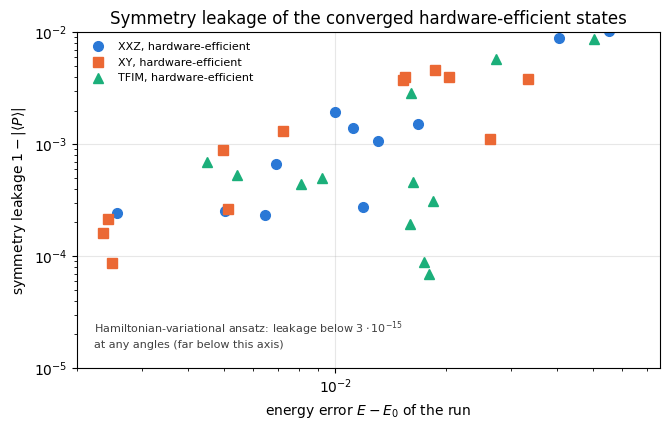

In [13]:
# ==============================================================================
# STEP 9: the Hamiltonian-variational ansatz, and the parity of every converged state
# ==============================================================================
def hva_num_params(layers):
    """Number of angles of the Hamiltonian-variational ansatz, Eq. (13): 2 per layer."""
    return 2 * layers


def hva_tfim(theta, N, layers, J=-1.0, h=1.0):
    """Hamiltonian-variational ansatz for the transverse-field Ising model, Eq. (13).

    MATH   |psi> = prod_l [ prod_q Rx(2 h beta_l) ] [ prod_bonds Rzz(2 J gamma_l) ] |->^N
           |->^N is the ground state of h sum_q X_q for h > 0 (the start of the adiabatic path).
           The gates inside one factor commute, so each exponential is exact; the two factors of a layer do
           not commute with each other, which is what makes the family expressive.
    IMPL   |->^N is Ry(-pi/2) on every qubit of |0..0>:  Ry(-pi/2)|0> = (|0>-|1>)/sqrt(2).
    COST   O(L N 2^N).
    """
    theta = theta.reshape(layers, 2)
    psi = zero_state(N)
    for q in range(N):                                         # |0..0> -> |-..->
        psi = apply_gate(psi, ry(-jnp.pi / 2), [q])
    for l in range(layers):
        gamma, beta = theta[l, 0], theta[l, 1]
        for q in range(N - 1):
            psi = apply_gate(psi, rzz(2.0 * J * gamma), [q, q + 1])
        for q in range(N):
            psi = apply_gate(psi, rx(2.0 * h * beta), [q])
    return psi


# --- CHECKPOINT: the HVA sits in the P = +1 sector at ANY angles -----------------------------------
th_hva_rand = jax.random.uniform(jax.random.PRNGKey(91), (64, hva_num_params(3)), minval=-jnp.pi, maxval=jnp.pi)
par_hva = np.asarray(jax.jit(jax.vmap(lambda t: parity(hva_tfim(t, N_SITES, 3))))(th_hva_rand))
print(f"HVA, 64 random parameter vectors: <P> in [{par_hva.min():.12f}, {par_hva.max():.12f}] "
      f"-> max leakage {np.max(1 - np.abs(par_hva)):.2e}")
assert np.max(1 - np.abs(par_hva)) < 1e3 * TOL
psi_hva0 = hva_tfim(jnp.zeros(hva_num_params(1)), N_SITES, 1)        # zero angles: the start |->^N itself
x_hva0 = np.asarray(all_local_expectations(psi_hva0))[:, 0]
print(f"HVA at zero angles: <X_q> = {x_hva0.min():+.12f} ... {x_hva0.max():+.12f}  (|->^N, the ground state of h_x sum X)")
assert np.max(np.abs(x_hva0 + 1)) < TOL

# --- parity of the hardware-efficient states that Section 8 converged to ---------------------------
print(f"\n{'model':>6s} {'median <P>':>11s} {'best-run <P>':>13s} {'median leakage':>15s} "
      f"{'best-run leakage':>17s} {'exact <P>':>10s}")
leak_tab = {}
for i, name in enumerate(MODEL_NAMES):
    pars = np.asarray(jax.jit(jax.vmap(lambda t: parity(ansatz_state(t))))(TH_FINAL[i]))
    errs = HIST[i, :, -1, 0]
    leak_tab[name] = (pars, errs)
    j = int(np.argmin(errs))
    print(f"{name:>6s} {np.median(pars):+11.4f} {pars[j]:+13.4f} {np.median(1 - np.abs(pars)):15.4f} "
          f"{1 - abs(pars[j]):17.2e} {float(parity(EXACT[name]['psi0'])):+10.4f}")


def spearman(a, b):
    """Spearman rank correlation (no ties): Pearson correlation of the ranks."""
    ra, rb = np.argsort(np.argsort(a)), np.argsort(np.argsort(b))
    return float(np.corrcoef(ra, rb)[0, 1])


# --- CHECKPOINT: leakage <= 2 (1 - F) <= 2 (E - E_0) / Delta for every run (Section 9.1) -------------------------
print(f"\n{'model':>6s} {'rank corr(E-E_0, leakage)':>26s} {'max leak / 2(1-F)':>18s} {'max leak / [2(E-E_0)/Delta]':>28s}")
for i, name in enumerate(MODEL_NAMES):
    pars, errs = leak_tab[name]
    leak, F_run = 1 - np.abs(pars), HIST[i, :, -1, 2]
    gap = EXACT[name]["E1"] - EXACT[name]["E0"]
    r1, r2 = np.max(leak / (2 * (1 - F_run))), np.max(leak / (2 * errs / gap))
    print(f"{name:>6s} {spearman(errs, leak):26.2f} {r1:18.3f} {r2:28.4f}")
    assert r1 <= 1 + 1e-9 and r2 <= 1 + 1e-9

fig, ax = plt.subplots(figsize=(6.8, 4.4))
for i, name in enumerate(MODEL_NAMES):
    pars, errs = leak_tab[name]
    ax.loglog(np.maximum(errs, 1e-12), np.maximum(1 - np.abs(pars), 1e-16), MARKERS[i], ms=7,
              color=PALETTE[i], label=f"{name}, hardware-efficient")
ax.set_ylim(1e-5, 1e-2)
ax.text(0.03, 0.06, "Hamiltonian-variational ansatz: leakage below $3\\cdot10^{-15}$\nat any angles (far below this axis)",
        transform=ax.transAxes, fontsize=8, color="0.25")
ax.set_xlabel(r"energy error $E-E_0$ of the run")
ax.set_ylabel(r"symmetry leakage $1-\vert\langle P\rangle\vert$")
ax.set_title("Symmetry leakage of the converged hardware-efficient states")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

**The Hamiltonian-variational ansatz is exactly symmetric.** Over 64 random parameter vectors its parity is
$1.000000000000$ to twelve printed digits, with a largest leakage of $2.8\cdot10^{-15}$, which is round-off.
The three-line proof above is confirmed: the family never leaves the $P=+1$ sector, so half of the Hilbert space is
removed from the search before the optimiser starts.

**The hardware-efficient ansatz learns the symmetry, approximately.** The converged states have a median leakage of
$1.2\cdot10^{-3}$ (XXZ and XY) and $5\cdot10^{-4}$ (TFIM), against the median of $0.94$ at random angles measured in
Section 5.3: minimising the energy has brought $\lvert\langle P\rangle\rvert$ to within $10^{-3}$ of one, for a
symmetry that the circuit has no structural reason to possess. The inequality chain above holds for every run (the
printed ratios are below one), but it is far from tight for the Ising chain: there the leakage is at most $0.43$ of
$2(1-F)$, so most of the infidelity of those states lies *inside* the even sector. That is also why the scatter plot
shows two different behaviours. For the XXZ and XY chains, leakage and energy error track each other (rank
correlations $0.87$ and $0.78$ over twelve runs); for the Ising chain they are uncorrelated (rank correlation
$0.06$), and its best run, with $E-E_0=4.5\cdot10^{-3}$, has a leakage of $6.9\cdot10^{-4}$, above the median.
For the Ising chain the energy error is dominated by the even-sector part of the error, which parity cannot see.

The leakage is a *diagnostic that costs nothing and needs no exact solution*: $\langle P\rangle$ is the expectation
value of one Pauli string, measurable on hardware in a single setting. A converged VQE run whose state has
$\lvert\langle P\rangle\rvert$ far from $1$ is announcing that it has not converged, without any reference state
being available.

> **Common pitfall.** "The ansatz respects the symmetry" is a claim about the *circuit*; a symmetric trained state does
> not establish it.
> The right check is the one above: evaluate the symmetry generator at random angles. If it is not conserved there,
> the family does not respect the symmetry, however symmetric a converged state happens to look.

## 10. Depth: expressivity, entanglement and trainability

### 10.1 Entanglement capacity of a depth-$L$ circuit

Cut the chain in the middle, between qubits $N/2-1$ and $N/2$, and write the state in Schmidt form
$\vert\psi\rangle=\sum_{k=1}^{r}s_k\vert a_k\rangle\vert b_k\rangle$ with Schmidt rank $r$. The entropy of $s_k^2$ is at
most that of the uniform distribution on $r$ values, $S_{\mathrm{half}}\le\log_2r$. Now count how gates change $r$.
A single-qubit rotation acts on one side only and maps $\vert a_k\rangle\vert b_k\rangle$ to another product of the
same form: $r$ is unchanged. A $CZ$ on a pair that does not straddle the cut is likewise a one-sided unitary. The one
$CZ$ per entangling layer that straddles the cut can be written as

$$CZ=\vert0\rangle\langle0\vert\otimes\mathbb 1+\vert1\rangle\langle1\vert\otimes Z ,$$

a sum of **two** products of one-sided operators, so it maps each Schmidt term to at most two product terms: $r$ at
most doubles. The start $\vert0\rangle^{\otimes N}$ has $r=1$, so after $L$ entangling layers $r\le2^L$, and since
$r$ also cannot exceed the dimension $2^{N/2}$ of either half,

$$S_{\mathrm{half}}\bigl(\vert\psi(\boldsymbol\theta)\rangle\bigr)\;\le\;\min(L,\,N/2)\ \text{bits}. \tag{9}$$

The count uses that $CZ$ has two terms in this decomposition (operator Schmidt rank two). A general two-qubit gate
has up to four, and a SWAP across the cut can raise the entropy by two bits, so the "one bit per gate" rule is a
property of controlled gates such as $CZ$ and CNOT and does not extend to every two-qubit gate.

This is a hard constraint on the family, independent of any optimiser. If the target ground state has
$S_{\mathrm{half}}>\min(L,N/2)$, no choice of angles can reach it. Equation (9) is the elementary version of the
entanglement-area-law argument that also underlies matrix-product states
([18 — MPS and TEBD](../ch07_tensor_networks/18_mps_tebd.ipynb)), where the bond dimension $\chi$ plays the role of
$2^L$.

### 10.2 Counting parameters

The second constraint is dimensional. A general $N$-qubit pure state has $2\cdot2^N-2$ real parameters (complex
amplitudes minus normalisation and global phase); for $N=6$ that is $126$, while the ansatz has $n=2N(L+1)=12(L+1)$,
so $n\ge126$ requires $L\ge10$. Notebook 41 measured, for a Haar-random target state at $N=4$, that the success rate rises
sharply where $n$ crosses $2\cdot2^N-2=30$, the overparametrisation threshold (Larocca *et al.*, 2023). A ground
state is not a random state: it is weakly entangled, symmetric and structured, so the relevant count may be far
smaller. The depth scan below measures which of the two constraints binds.

depth scan: 5 depths x 3 models x 8 restarts x 250 iterations in 21.1 s

  L    n Eq.(9) bound |             XXZ dE/F/S |              XY dE/F/S |            TFIM dE/F/S
  1   24            1 |  0.0379  0.995  0.0228 |  0.1373  0.983  0.0363 |  0.2131  0.642  0.0127
  2   36            2 |  0.0145  0.998  0.0384 |  0.0274  0.997  0.1028 |  0.1252  0.857  0.1872
  3   48            3 |  0.0115  0.999  0.0426 |  0.0201  0.998  0.1148 |  0.0355  0.987  0.3893
  4   60            3 |  0.0102  0.999  0.0432 |  0.0136  0.998  0.1219 |  0.0124  0.997  0.4438
  6   84            3 |  0.0123  0.998  0.0436 |  0.0099  0.999  0.1226 |  0.0094  0.997  0.4521

exact half-chain entropies: XXZ 0.0498, XY 0.1248, TFIM 0.4732


permutation p-values, final E - E_0 at L=4 against L=6 (8 restarts each): XXZ 0.95, XY 0.66, TFIM 0.75


control, L=1 against L=4 for the Ising chain (a real difference): 0.0037


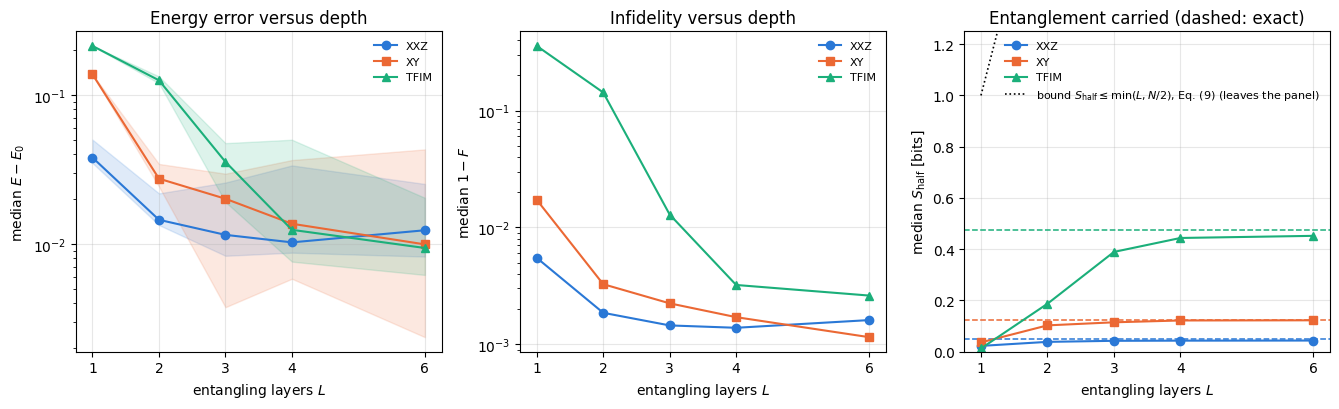

In [14]:
# ==============================================================================
# STEP 10: energy error, fidelity and entanglement versus the number of layers
# ==============================================================================
DEPTHS = (1, 2, 3, 4, 6)
R_DEPTH, T_DEPTH, R_DEPTH_HVA = 8, 250, 12
depth_rows = []
t0 = time.perf_counter()
for L in DEPTHS:
    n_L = hea_num_params(N_SITES, L)
    th_L, ks_L = random_starts(R_DEPTH, n_L, seed=41 + L)
    run_L = jax.jit(jax.vmap(lambda c, p, e: vqe_run(c, p, e, th_L, ks_L, LR_BEST, T_DEPTH, layers=L)[1]))
    h = np.asarray(jax.block_until_ready(run_L(C_STACK, PSI_STACK, E0_STACK)))     # (3, runs, steps, 9)
    depth_rows.append(h)
print(f"depth scan: {len(DEPTHS)} depths x 3 models x {R_DEPTH} restarts x {T_DEPTH} iterations "
      f"in {time.perf_counter() - t0:.1f} s")

print(f"\n{'L':>3s} {'n':>4s} {'Eq.(9) bound':>12s} | " +
      " | ".join(f"{k + ' dE/F/S':>22s}" for k in MODEL_NAMES))
for j, L in enumerate(DEPTHS):
    cells = []
    for i, name in enumerate(MODEL_NAMES):
        h = depth_rows[j][i]
        cells.append(f"{np.median(h[:, -1, 0]):7.4f} {np.median(h[:, -1, 2]):6.3f} {np.median(h[:, -1, 1]):7.4f}")
    print(f"{L:3d} {hea_num_params(N_SITES, L):4d} {min(L, N_SITES // 2):12d} | " + " | ".join(f"{c:>22s}" for c in cells))
print("\nexact half-chain entropies: " +
      ", ".join(f"{k} {EXACT[k]['obs'][0]:.4f}" for k in MODEL_NAMES))
print("permutation p-values, final E - E_0 at L=4 against L=6 (8 restarts each): " + ", ".join(
    f"{k} {perm_pvalue(depth_rows[DEPTHS.index(4)][i][:, -1, 0], depth_rows[DEPTHS.index(6)][i][:, -1, 0], seed=4 + i):.2f}"
    for i, k in enumerate(MODEL_NAMES)))
print("control, L=1 against L=4 for the Ising chain (a real difference): "
      f"{perm_pvalue(depth_rows[0][MODEL_NAMES.index('TFIM')][:, -1, 0], depth_rows[DEPTHS.index(4)][MODEL_NAMES.index('TFIM')][:, -1, 0], seed=9):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
ns = [hea_num_params(N_SITES, L) for L in DEPTHS]
for i, name in enumerate(MODEL_NAMES):
    med_dE = [np.median(depth_rows[j][i][:, -1, 0]) for j in range(len(DEPTHS))]
    lo_dE = [np.percentile(depth_rows[j][i][:, -1, 0], 25) for j in range(len(DEPTHS))]
    hi_dE = [np.percentile(depth_rows[j][i][:, -1, 0], 75) for j in range(len(DEPTHS))]
    med_F = [np.median(depth_rows[j][i][:, -1, 2]) for j in range(len(DEPTHS))]
    med_S = [np.median(depth_rows[j][i][:, -1, 1]) for j in range(len(DEPTHS))]
    axes[0].semilogy(DEPTHS, med_dE, MARKERS[i] + "-", ms=6, color=PALETTE[i], label=name)
    axes[0].fill_between(DEPTHS, lo_dE, hi_dE, color=PALETTE[i], alpha=0.15)
    axes[1].semilogy(DEPTHS, np.maximum(1 - np.array(med_F), 1e-6), MARKERS[i] + "-", ms=6, color=PALETTE[i], label=name)
    axes[2].plot(DEPTHS, med_S, MARKERS[i] + "-", ms=6, color=PALETTE[i], label=name)
    axes[2].axhline(EXACT[name]["obs"][0], color=PALETTE[i], ls="--", lw=1.1)
axes[2].plot(DEPTHS, [min(L, N_SITES // 2) for L in DEPTHS], "k:", lw=1.2,
             label=r"bound $S_{\rm half}\leq \min(L,N/2)$, Eq. (9) (leaves the panel)")
axes[2].set_ylim(0, 1.25)
axes[0].set_xlabel("entangling layers $L$"); axes[0].set_ylabel(r"median $E-E_0$")
axes[0].set_title("Energy error versus depth"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("entangling layers $L$"); axes[1].set_ylabel(r"median $1-F$")
axes[1].set_title("Infidelity versus depth"); axes[1].legend(fontsize=8)
axes[2].set_xlabel("entangling layers $L$"); axes[2].set_ylabel(r"median $S_{\rm half}$ [bits]")
axes[2].set_title("Entanglement carried (dashed: exact)"); axes[2].legend(fontsize=8)
for a in axes:
    a.set_xticks(DEPTHS)
fig.tight_layout(); plt.show()

**Depth helps until the optimiser floor is reached.** For the critical Ising chain the median energy error falls from
$0.213$ at $L=1$ through $0.125$ and $0.036$ to $0.0124$ at $L=4$ and $0.0094$ at $L=6$, and the median fidelity rises
from $0.64$ to $0.997$. The first three steps are large and robust: at $L=1$ all eight restarts end at the same
$0.2130$, at $L=2$ the best of eight is $0.117$. From $L=3$ on, every model sits near the $10^{-2}$ floor that
Section 8.1 traced to the constant Adam step, and the remaining differences are not significant with eight restarts:
XXZ goes $0.0115\to0.0102\to0.0123$ for $L=3,4,6$, but the eight final errors at $L=4$ and at $L=6$ interleave
(the permutation test printed above gives $p=0.95$), and the same holds for the other two models ($p=0.66$ and
$0.75$), whereas the same test separates the Ising chain at $L=1$ from $L=4$ with $p=0.004$. What the table shows for the two nearly
polarised chains is that two entangling layers already bring them to the optimiser floor; it does not show that
more depth hurts.

**The entanglement bound of Eq. (9) is not what limits the accuracy here.** The bound allows $\min(L,3)$ bits; the
targets need $0.05$, $0.12$ and $0.47$ bits, so even $L=1$ has enough capacity for all three. Yet at $L=1$ the optimised
Ising state carries only $0.013$ bits and misses the energy by $0.21$. With a single $CZ$ layer the entangling gates are
fixed and only the rotations before them can tune how much entanglement is made, and the restarts all find the same
nearly unentangled compromise. The entanglement produced climbs with depth — $0.013$, $0.187$, $0.389$, $0.444$,
$0.452$ bits against the exact $0.473$ — always below the target and always far below the ceiling. Equation (9) is a
necessary condition only: what limits a shallow hardware-efficient circuit is the shape of the reachable set, and its
entanglement capacity is not the binding constraint.

**The parameter count tells the same story.** All the depths here have $n=24$ to $84$ angles, and a general
six-qubit state needs $2\cdot2^N-2=126$: the counting threshold that notebook 41 located for a **Haar-random** target
(there at $N=4$, where it is $30$) is never crossed, and yet the median fidelity reaches $0.997$. A ground state is
not a random state. It is weakly entangled, symmetric and structured, and a circuit with far fewer than
$2\cdot2^N-2$ parameters can approximate it well. The counting threshold is the right criterion for the worst case
and a pessimistic one for these ground states.

### 10.3 The same study with the Hamiltonian-variational ansatz

The hardware-efficient family buys its expressivity with parameters: $12(L+1)$ of them at $N=6$. The
Hamiltonian-variational ansatz of Eq. (13) has $2L$ — at $L=6$ that is twelve angles against eighty-four. If a
problem-inspired structure is worth anything, it should show here: the same critical Ising ground state, the same
optimiser, a small fraction of the parameters.

The two families live on landscapes with different curvature scales, so re-using the step size tuned in Section 7
would be exactly the mistake that notebook 41 warned against. Each depth therefore gets its own sweep over four step
sizes — a nested `vmap`, one compilation per depth — and we report the step with the smallest median. We also report
the **best** run next to the median, as a measure of how much the restarts disagree.

HVA depth scan (4 step sizes per depth) in 18.7 s

critical Ising chain, N=6: two ansatz families
  L |  HEA n  median E-E_0      best  median F |  HVA n  best lr  median E-E_0      best  median F
  1 |     24       0.21307   0.21304    0.6420 |      -        -             -         -         -
  2 |     36       0.12523   0.11679    0.8571 |      4     0.20       0.11746   0.07450    0.9522
  3 |     48       0.03550   0.00802    0.9871 |      -        -             -         -         -
  4 |     60       0.01242   0.00551    0.9968 |      8     0.10       0.04766   0.01811    0.9812
  6 |     84       0.00938   0.00511    0.9974 |     12     0.10       0.02763   0.01456    0.9892
  8 |      -             -         -         - |     16     0.10       0.01726   0.01033    0.9936


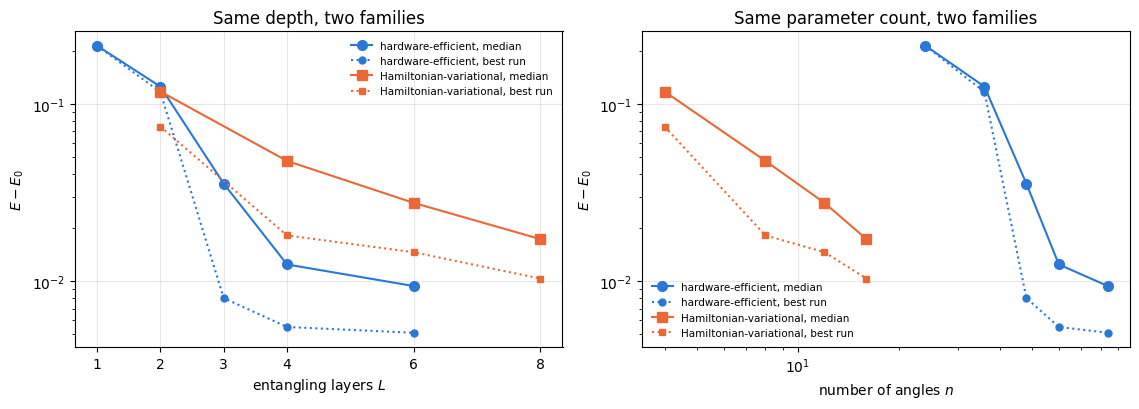

In [15]:
# ==============================================================================
# STEP 11: HVA depth scan on the critical Ising chain, each depth at its own best step size
# ==============================================================================
HVA_DEPTHS = (2, 4, 6, 8)
LR_GRID_HVA = jnp.asarray([0.05, 0.1, 0.2, 0.4], dtype=RDTYPE)
hva_rows, hva_lr = [], []
t0 = time.perf_counter()
for L in HVA_DEPTHS:
    nL = hva_num_params(L)
    th_L, ks_L = random_starts(R_DEPTH_HVA, nL, seed=71 + L)

    def cost_hva(t, L=L):
        return energy(model_terms(N_SITES, c_tfim), hva_tfim(t, N_SITES, L))

    def mon_hva(t, L=L):
        psi = hva_tfim(t, N_SITES, L)
        return jnp.stack([energy(model_terms(N_SITES, c_tfim), psi) - E0_tfim,
                          entanglement_entropy(psi, range(N_SITES // 2)),
                          fidelity_pure(psi0_tfim, psi)])

    # nested vmap: one compilation for the whole (step size x restart) grid at this depth
    h = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(lambda lr: jax.vmap(lambda t, k: train(
        t, k, grad_exact(cost_hva), opt_adam(lr), mon_hva, T_DEPTH)[1])(th_L, ks_L)))(LR_GRID_HVA)))
    j_best = int(np.argmin(np.median(h[:, :, -1, 0], axis=1)))
    hva_rows.append(h[j_best]); hva_lr.append(float(np.asarray(LR_GRID_HVA)[j_best]))
print(f"HVA depth scan ({len(LR_GRID_HVA)} step sizes per depth) in {time.perf_counter() - t0:.1f} s")

i_tfim = MODEL_NAMES.index("TFIM")
print(f"\ncritical Ising chain, N={N_SITES}: two ansatz families")
print(f"{'L':>3s} | {'HEA n':>6s} {'median E-E_0':>13s} {'best':>9s} {'median F':>9s} | "
      f"{'HVA n':>6s} {'best lr':>8s} {'median E-E_0':>13s} {'best':>9s} {'median F':>9s}")
for L in sorted(set(DEPTHS) | set(HVA_DEPTHS)):
    hea_cell = "     -             -         -         -"
    if L in DEPTHS:
        hh = depth_rows[DEPTHS.index(L)][i_tfim]
        hea_cell = (f"{hea_num_params(N_SITES, L):6d} {np.median(hh[:, -1, 0]):13.5f} {hh[:, -1, 0].min():9.5f} "
                    f"{np.median(hh[:, -1, 2]):9.4f}")
    hva_cell = "     -        -             -         -         -"
    if L in HVA_DEPTHS:
        hv = hva_rows[HVA_DEPTHS.index(L)]
        hva_cell = (f"{hva_num_params(L):6d} {hva_lr[HVA_DEPTHS.index(L)]:8.2f} {np.median(hv[:, -1, 0]):13.5f} "
                    f"{hv[:, -1, 0].min():9.5f} {np.median(hv[:, -1, 2]):9.4f}")
    print(f"{L:3d} | {hea_cell} | {hva_cell}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
med_hea = [np.median(depth_rows[j][i_tfim][:, -1, 0]) for j in range(len(DEPTHS))]
med_hva = [np.median(hva_rows[j][:, -1, 0]) for j in range(len(HVA_DEPTHS))]
best_hea = [depth_rows[j][i_tfim][:, -1, 0].min() for j in range(len(DEPTHS))]
best_hva = [hva_rows[j][:, -1, 0].min() for j in range(len(HVA_DEPTHS))]
axes[0].semilogy(DEPTHS, med_hea, MARKERS[0] + "-", ms=7, color=PALETTE[0], label="hardware-efficient, median")
axes[0].semilogy(DEPTHS, best_hea, MARKERS[0] + ":", ms=5, color=PALETTE[0], label="hardware-efficient, best run")
axes[0].semilogy(HVA_DEPTHS, med_hva, MARKERS[1] + "-", ms=7, color=PALETTE[1], label="Hamiltonian-variational, median")
axes[0].semilogy(HVA_DEPTHS, best_hva, MARKERS[1] + ":", ms=5, color=PALETTE[1],
                 label="Hamiltonian-variational, best run")
axes[0].set_xlabel("entangling layers $L$"); axes[0].set_ylabel(r"$E-E_0$")
axes[0].set_xticks(sorted(set(DEPTHS) | set(HVA_DEPTHS)))
axes[0].set_title("Same depth, two families"); axes[0].legend(fontsize=7.5)

axes[1].loglog([hea_num_params(N_SITES, L) for L in DEPTHS], med_hea, MARKERS[0] + "-", ms=7,
               color=PALETTE[0], label="hardware-efficient, median")
axes[1].loglog([hea_num_params(N_SITES, L) for L in DEPTHS], best_hea, MARKERS[0] + ":", ms=5,
               color=PALETTE[0], label="hardware-efficient, best run")
axes[1].loglog([hva_num_params(L) for L in HVA_DEPTHS], med_hva, MARKERS[1] + "-", ms=7,
               color=PALETTE[1], label="Hamiltonian-variational, median")
axes[1].loglog([hva_num_params(L) for L in HVA_DEPTHS], best_hva, MARKERS[1] + ":", ms=5,
               color=PALETTE[1], label="Hamiltonian-variational, best run")
axes[1].set_xlabel("number of angles $n$"); axes[1].set_ylabel(r"$E-E_0$")
axes[1].set_title("Same parameter count, two families"); axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

The two families answer two different questions, and the two panels separate them.

**At equal depth the hardware-efficient ansatz wins from $L=3$ on.** At $L=2$ the two medians are equal within the
scatter ($0.125$ against $0.117$); at $L=4$ and $L=6$ the hardware-efficient circuit reaches $0.0124$ and $0.0094$
against $0.048$ and $0.028$ for the Hamiltonian-variational one. That is expected: at $L=6$ the one family has $84$
free angles and the other has $12$.

**At equal parameter count the ranking reverses, by an order of magnitude.** With $16$ angles ($L=8$) the
Hamiltonian-variational ansatz reaches a median error of $0.017$ and a median fidelity of $0.994$; the
hardware-efficient circuit with the comparable $24$ angles ($L=1$) is stuck at $0.213$ in every restart, with fidelity
$0.642$, a factor of twelve worse. Even the four-angle Hamiltonian-variational circuit ($L=2$, median $0.117$) beats
the $24$-angle hardware-efficient one. The structure taken from the Hamiltonian is worth a large factor in
parameters, which on hardware is a large factor in parameter-shift circuits per iteration.

**Both landscapes are benign at these sizes.** The best run is within a factor of three of the median for every
Hamiltonian-variational depth and within a factor of two and a half for the hardware-efficient family at $L=4$ and $6$, so
neither family is dominated by bad local minima at $N=6$. The comparison does depend on the initial state of
Eq. (13): Exercise 4 repeats the scan from $\vert+\rangle^{\otimes N}$, the highest state of the field term, where
the problem-inspired circuit is far worse at every depth up to $L=6$. A problem-inspired ansatz is only as good as the physics put into it.

> **Numerical practice.** The step sizes were re-tuned per depth and per family (the chosen values are printed in
> the table). Carrying over the $\eta=0.4$ of Section 7 would have made the Hamiltonian-variational family look worse
> than it is (at $L=8$ the median at $\eta=0.4$ is about three times the median at the selected step), and would have
> been a statement about the step size rather than about the ansatz.

## 11. Across the phase diagram of the transverse-field Ising chain

### 11.1 The physics

Take the TFIM of Eq. (6), $H=-\sum_qZ_qZ_{q+1}+h\sum_qX_q$, and vary $h$. The two limits are elementary:

* $h=0$: the Hamiltonian is diagonal in the $Z$ basis and the two ground states are
  $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$ — **ferromagnetic order**, twofold degenerate;
* $h\to\infty$: the field wins, and the unique ground state is the product state
  $\vert-\rangle^{\otimes N}$ with $\langle X_q\rangle=-1$ — the **paramagnetic** phase.

In the thermodynamic limit these are separated by a quantum critical point at $\lvert h\rvert=1$, where the gap
closes as $1/N$ and the half-chain entanglement grows logarithmically with $N$. On a finite open chain there is no
true degeneracy: tunnelling between the two ordered configurations splits the doublet by an amount that vanishes
**exponentially** in $N$, and the two lowest eigenvectors are, deep in the ordered phase, close to the symmetric and
antisymmetric combinations

$$\vert C_\pm\rangle\simeq\frac{\vert0\cdots0\rangle\pm\vert1\cdots1\rangle}{\sqrt2},
  \qquad P\vert C_\pm\rangle=\pm\vert C_\pm\rangle ,$$

cat states with one bit of half-chain entanglement. The parity labels are exact at every $h$ (Section 5.1); the
printed table below confirms that the ground state is the even one, $\vert C_+\rangle$, and the first excited state
the odd one.

### 11.2 What that does to the fidelity

Deep in the ordered phase the exact ground state returned by Lanczos is the cat state $\vert C_+\rangle$. Consider
any state inside the two-dimensional doublet, $\vert\psi\rangle=a\vert C_+\rangle+b\vert C_-\rangle$. Its parity is
$\langle P\rangle=\lvert a\rvert^2-\lvert b\rvert^2$ and its energy error is $\lvert b\rvert^2\Delta$, so

$$E-E_0=\frac{1-\langle P\rangle}{2}\,\Delta,\qquad F=\lvert a\rvert^2=\frac{1+\langle P\rangle}{2}. \tag{10}$$

The **symmetry-broken** member $(\vert C_+\rangle+\vert C_-\rangle)/\sqrt2\simeq\vert0\cdots0\rangle$ has
$\langle P\rangle=0$: energy error $\Delta/2$, invisible when the splitting is exponentially small, and fidelity
exactly $1/2$. So we should expect, and will measure, a region of the phase diagram where the energy error is
essentially zero while the fidelity sits at $1/2$. It signals neither an optimiser failure nor a bug: when
the ground level is (nearly) degenerate, fidelity with one particular member of it is the wrong figure of merit, as
Section 3.3 noted. The physically meaningful quantities there are *observables* (the order parameter, the
correlators) and the fidelity with the whole doublet,
$F_{\text{sub}}=\lvert\langle C_+\vert\psi\rangle\rvert^2+\lvert\langle C_-\vert\psi\rangle\rvert^2$, which we also
measure; Eq. (10) also predicts the energy error from the measured parity alone.

The field sweep is one compiled program: the coefficient vector $\mathbf c(h)=(0,0,-1,h)$ is traced, and `vmap` runs
over its values.

In [16]:
# ==============================================================================
# STEP 12: exact references across the field sweep
# ==============================================================================
H_GRID = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0])
ref_h = {"E0": [], "E1": [], "gap": [], "S": [], "psi0": [], "psi1": []}
for h in H_GRID:
    terms_h = model_terms(N_SITES, jnp.asarray((0.0, 0.0, -1.0, float(h)), dtype=RDTYPE))
    w, V = np.linalg.eigh(np.asarray(dense_hamiltonian(terms_h, N_SITES)))
    p0 = jnp.asarray(V[:, 0], dtype=CDTYPE).reshape((2,) * N_SITES)
    p1 = jnp.asarray(V[:, 1], dtype=CDTYPE).reshape((2,) * N_SITES)
    ref_h["E0"].append(float(w[0])); ref_h["E1"].append(float(w[1]))
    ref_h["gap"].append(float(w[1] - w[0])); ref_h["S"].append(float(entanglement_entropy(p0, range(N_SITES // 2))))
    ref_h["psi0"].append(p0); ref_h["psi1"].append(p1)
print(f"{'h':>5s} {'E_0':>10s} {'E_1 - E_0':>12s} {'S_half':>8s} {'parity of |0>':>14s} {'parity of |1>':>14s}")
for j, h in enumerate(H_GRID):
    print(f"{h:5.2f} {ref_h['E0'][j]:10.5f} {ref_h['gap'][j]:12.3e} {ref_h['S'][j]:8.4f} "
          f"{float(parity(ref_h['psi0'][j])):+14.3f} {float(parity(ref_h['psi1'][j])):+14.3f}")

    h        E_0    E_1 - E_0   S_half  parity of |0>  parity of |1>
 0.20   -5.08031    1.229e-04   0.9999         +1.000         -1.000
 0.40   -5.32762    6.882e-03   0.9903         +1.000         -1.000
 0.60   -5.77092    6.018e-02   0.9031         +1.000         -1.000
 0.80   -6.43971    2.194e-01   0.6868         +1.000         -1.000
 1.00   -7.29623    4.821e-01   0.4732         +1.000         -1.000
 1.20   -8.26934    8.055e-01   0.3334         +1.000         -1.000
 1.50   -9.84757    1.343e+00   0.2171         +1.000         -1.000
 2.00  -12.63096    2.293e+00   0.1278         +1.000         -1.000


field sweep: 8 fields x 8 restarts x 250 iterations in 6.1 s

    h        gap  S_exact  median E-E_0   Eq.(10)  best E-E_0  median F median F_sub median S_vqe  median <P>  1-F bound
 0.20  1.229e-04   0.9999       0.00020   0.00006     0.00007    0.5000       0.9999       0.0001     +0.0000      1.000
 0.40  6.882e-03   0.9903       0.00377   0.00343     0.00359    0.5018       0.9999       0.0015     +0.0037      0.548
 0.60  6.018e-02   0.9031       0.02999   0.02874     0.02951    0.5222       0.9996       0.0112     +0.0449      0.498
 0.80  2.194e-01   0.6868       0.06367   0.03109     0.00854    0.8477       0.9881       0.3515     +0.7165      0.290
 1.00  4.821e-01   0.4732       0.01873   0.00016     0.00251    0.9939       0.9939       0.4200     +0.9994      0.039
 1.20  8.055e-01   0.3334       0.00894   0.00031     0.00597    0.9975       0.9975       0.3130     +0.9992      0.011
 1.50  1.343e+00   0.2171       0.01607   0.00211     0.00557    0.9967       0.9968       

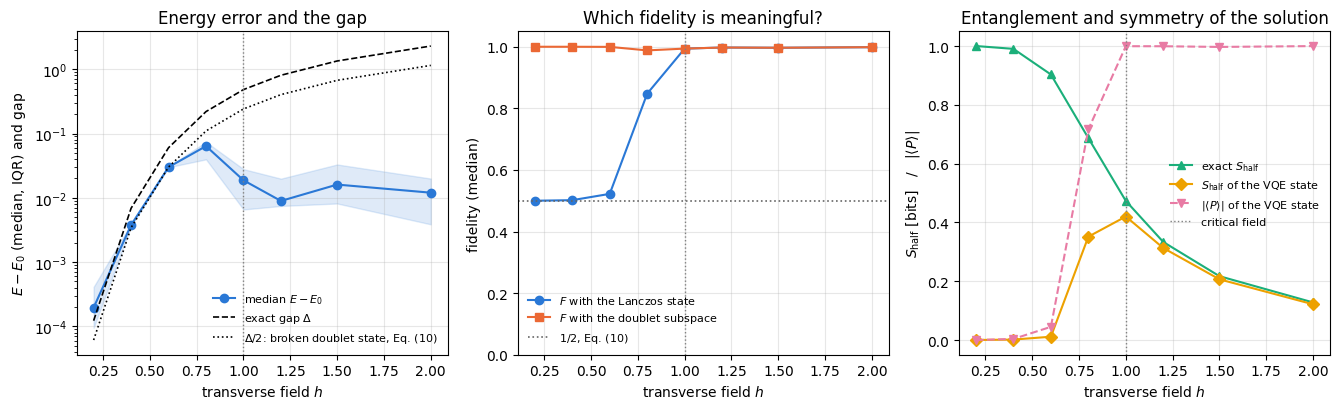

In [17]:
# ==============================================================================
# STEP 13: VQE across the sweep -- one compilation, vmapped over the field
# ==============================================================================
R_SWEEP, T_SWEEP, L_SWEEP = 8, 250, 4
n_sweep = hea_num_params(N_SITES, L_SWEEP)
th_sw, ks_sw = random_starts(R_SWEEP, n_sweep, seed=51)
C_H = jnp.stack([jnp.asarray((0.0, 0.0, -1.0, float(h)), dtype=RDTYPE) for h in H_GRID])
PSI0_H = jnp.stack(ref_h["psi0"])
PSI1_H = jnp.stack(ref_h["psi1"])
E0_H = jnp.asarray(ref_h["E0"], dtype=RDTYPE)


def sweep_one(c, p0, p1, e0):
    """Train R_SWEEP restarts at one field.

    Monitor: (E - E_0, fidelity with the Lanczos state, fidelity with the doublet subspace,
              half-chain entropy, parity) -- five numbers per iteration per restart.
    """
    cost = lambda t: vqe_cost(t, c, layers=L_SWEEP)

    def monitor(t):
        psi = ansatz_state(t, layers=L_SWEEP)
        f0, f1 = fidelity_pure(p0, psi), fidelity_pure(p1, psi)
        return jnp.stack([energy(model_terms(N_SITES, c), psi) - e0, f0, f0 + f1,
                          entanglement_entropy(psi, range(N_SITES // 2)), parity(psi)])

    return jax.vmap(lambda t, k: train(t, k, grad_exact(cost), opt_adam(LR_BEST), monitor, T_SWEEP)[1])(th_sw, ks_sw)


t0 = time.perf_counter()
H_SW = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(sweep_one))(C_H, PSI0_H, PSI1_H, E0_H)))
print(f"field sweep: {len(H_GRID)} fields x {R_SWEEP} restarts x {T_SWEEP} iterations "
      f"in {time.perf_counter() - t0:.1f} s")

print(f"\n{'h':>5s} {'gap':>10s} {'S_exact':>8s} {'median E-E_0':>13s} {'Eq.(10)':>9s} {'best E-E_0':>11s} "
      f"{'median F':>9s} {'median F_sub':>12s} {'median S_vqe':>12s} {'median <P>':>11s} {'1-F bound':>10s}")
for j, h in enumerate(H_GRID):
    med_dE = np.median(H_SW[j, :, -1, 0])
    pred_10 = np.median((1 - H_SW[j, :, -1, 4]) / 2 * ref_h["gap"][j])    # doublet prediction from the parity
    print(f"{h:5.2f} {ref_h['gap'][j]:10.3e} {ref_h['S'][j]:8.4f} {med_dE:13.5f} {pred_10:9.5f} "
          f"{H_SW[j, :, -1, 0].min():11.5f} "
          f"{np.median(H_SW[j, :, -1, 1]):9.4f} {np.median(H_SW[j, :, -1, 2]):12.4f} "
          f"{np.median(H_SW[j, :, -1, 3]):12.4f} {np.median(H_SW[j, :, -1, 4]):+11.4f} "
          f"{min(1.0, med_dE / ref_h['gap'][j]):10.3f}")
print("(Eq.(10) column: median over restarts of (1 - <P>) Delta / 2, the energy error of a doublet state with that parity)")

# --- CHECKPOINT: Eq. (10) in the ordered phase, h <= 0.6, run by run ----------------------------------------------
for j in np.where(H_GRID <= 0.6)[0]:
    pred = (1 - H_SW[j, :, -1, 4]) / 2 * ref_h["gap"][j]
    rel = np.median(np.abs(H_SW[j, :, -1, 0] - pred) / H_SW[j, :, -1, 0])
    print(f"h = {H_GRID[j]:.1f}: median relative deviation of E - E_0 from Eq. (10): {rel:.3f};  "
          f"wrong control 'E - E_0 = Delta': {np.median(np.abs(H_SW[j, :, -1, 0] - ref_h['gap'][j]) / H_SW[j, :, -1, 0]):.2f}")
    if H_GRID[j] >= 0.4:      # at h = 0.2 the splitting is below the ansatz error itself (see text)
        assert rel < 0.15 and np.median(np.abs(H_SW[j, :, -1, 0] - ref_h["gap"][j]) / H_SW[j, :, -1, 0]) > 0.5

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
axes[0].semilogy(H_GRID, [np.median(H_SW[j, :, -1, 0]) for j in range(len(H_GRID))], MARKERS[0] + "-",
                 ms=6, color=PALETTE[0], label=r"median $E-E_0$")
axes[0].fill_between(H_GRID, [np.percentile(H_SW[j, :, -1, 0], 25) for j in range(len(H_GRID))],
                     [np.percentile(H_SW[j, :, -1, 0], 75) for j in range(len(H_GRID))],
                     color=PALETTE[0], alpha=0.15)
axes[0].semilogy(H_GRID, ref_h["gap"], "k--", lw=1.2, label=r"exact gap $\Delta$")
axes[0].semilogy(H_GRID, np.asarray(ref_h["gap"]) / 2, "k:", lw=1.2, label=r"$\Delta/2$: broken doublet state, Eq. (10)")
axes[0].axvline(1.0, color="0.5", lw=1, ls=":")
axes[0].set_xlabel("transverse field $h$"); axes[0].set_ylabel(r"$E-E_0$ (median, IQR) and gap")
axes[0].set_title("Energy error and the gap"); axes[0].legend(fontsize=8)

axes[1].plot(H_GRID, [np.median(H_SW[j, :, -1, 1]) for j in range(len(H_GRID))], MARKERS[0] + "-",
             ms=6, color=PALETTE[0], label=r"$F$ with the Lanczos state")
axes[1].plot(H_GRID, [np.median(H_SW[j, :, -1, 2]) for j in range(len(H_GRID))], MARKERS[1] + "-",
             ms=6, color=PALETTE[1], label=r"$F$ with the doublet subspace")
axes[1].axhline(0.5, color="0.4", ls=":", lw=1.2, label=r"$1/2$, Eq. (10)")
axes[1].axvline(1.0, color="0.5", lw=1, ls=":")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("transverse field $h$"); axes[1].set_ylabel("fidelity (median)")
axes[1].set_title("Which fidelity is meaningful?"); axes[1].legend(fontsize=8)

axes[2].plot(H_GRID, ref_h["S"], MARKERS[2] + "-", ms=6, color=PALETTE[2], label=r"exact $S_{\rm half}$")
axes[2].plot(H_GRID, [np.median(H_SW[j, :, -1, 3]) for j in range(len(H_GRID))], MARKERS[3] + "-", ms=6,
             color=PALETTE[3], label=r"$S_{\rm half}$ of the VQE state")
axes[2].plot(H_GRID, [np.median(np.abs(H_SW[j, :, -1, 4])) for j in range(len(H_GRID))], MARKERS[4] + "--", ms=6,
             color=PALETTE[4], label=r"$\vert\langle P\rangle\vert$ of the VQE state")
axes[2].axvline(1.0, color="0.5", lw=1, ls=":", label="critical field")
axes[2].set_xlabel("transverse field $h$"); axes[2].set_ylabel(r"$S_{\rm half}$ [bits]   /   $\vert\langle P\rangle\vert$")
axes[2].set_title("Entanglement and symmetry of the solution"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 11.3 Reading the sweep

**Equation (10) in the ordered phase.** At $h=0.2$ the median fidelity with the Lanczos ground state is $0.5000$
while the fidelity with the two-dimensional doublet is $0.9999$, and the median energy error is $2.0\cdot10^{-4}$.
The variational state is an essentially perfect member of the doublet with $\langle P\rangle=0.000$, the
symmetry-broken combination of Eq. (10). Quoting $F=0.5$ as a failure would be a misreading; $F_{\text{sub}}=0.9999$
is the meaningful number. At this field the splitting is so small ($\Delta/2=6\cdot10^{-5}$) that the energy error
is dominated by the part of the state outside the doublet, and Eq. (10) accounts for only a third of it. At $h=0.4$
and $h=0.6$ the doublet term dominates, and Eq. (10) predicts the measured energy error from the measured parity
alone, run by run, to $9\%$ and $4\%$ (median relative deviation), while the control "$E-E_0=\Delta$" misses by
$80$ to $100\%$.

**The extra columns identify what the optimiser found.** At $h\le0.6$ the half-chain entropy of the variational
state is $0.0001$, $0.0015$, $0.011$ bits while the exact ground state has $1.00$, $0.99$, $0.90$ bits, and the
variational parity is $0.000$, $0.004$, $0.045$ against the exact $+1$. The optimiser found a **symmetry-broken,
essentially unentangled** state, one of the two ferromagnetic configurations, rather than their cat-like
superposition. At $h=0.2$ that costs only $\Delta/2=6\cdot10^{-5}$ in energy, less than the error the ansatz makes
anyway. At $h=0.6$ it costs $\Delta/2=0.030$, three times the optimiser floor of Section 8.1 and the largest part of
the measured error $0.030$, and still every restart stays in the broken state: a nearly product state is easy to
reach from random angles, and a shallow circuit started there does not find the one-bit cat state. Between $h=0.6$ and $h=1.0$ the parity climbs $0.045\to0.72\to0.9994$ and the
entropy $0.011\to0.35\to0.42$, as the splitting grows to $0.22$ and $0.48$.

**The hardest field is $h=0.8$, below the critical point.** The median energy error peaks there at $0.064$, against
$0.019$ at $h=1$ and $0.0002$ at $h=0.2$, and the spread across restarts is largest there too (best run $0.0085$). That is the crossover region: the doublet
splitting, $0.22$, is large enough that the symmetry-broken solution costs $0.11$, but the true ground state still
carries $0.69$ bits of entanglement, more than at criticality.

**A correction to a common expectation.** "Entanglement peaks at the critical point" refers to the scaling with
$N$ rather than to the value at a given $N$. Here the exact half-chain entropy *decreases* monotonically with $h$,
from $1.00$ bit deep in the ordered phase to $0.13$ at $h=2$, and the critical value $0.47$ is in between. The
ordered phase of a finite open chain has a cat-state ground state whose entanglement approaches one bit
**independently of $N$**, while the critical entropy of an open chain grows like $\tfrac{c}{6}\log_2N$ with central
charge $c=\tfrac12$, i.e. $\tfrac1{12}\log_2N$ (Calabrese and Cardy, 2004): $1/12$ of a bit per doubling of $N$,
so the critical value overtakes the cat-state bit only for very long chains. What distinguishes the
critical point is the scaling with $N$ of both the entropy and the gap, which closes as $1/N$ there and
exponentially in the ordered phase; a single size $N=6$ cannot show either.

**The certificate of Eq. (5) degrades as the gap closes.** The last column is $(E-E_0)/\Delta$, the bound on the
infidelity that a practitioner could quote without knowing the exact state. At $h=2$ it reads $0.005$ against a true
infidelity of $0.0015$, a usable certificate. At $h=0.2$ it reads $1.000$, i.e. nothing at all, because the gap is
$1.2\cdot10^{-4}$. Where the gap closes, the energy stops saying anything about the state.

## 12. An excited state: variational quantum deflation

VQE minimises. To get the *first excited* state one changes the cost so that its minimum is the first excited state.
**Variational quantum deflation** (Higgott, Wang and Brierley, 2019) adds an orthogonality penalty: having found an
approximation $\vert\psi_\star\rangle$ to the ground state, minimise

$$C_1(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle
  +\beta\,\bigl\lvert\langle\psi_\star\vert\psi(\boldsymbol\theta)\rangle\bigr\rvert^{2} . \tag{11}$$

### 12.1 The required size of $\beta$

Suppose $\vert\psi_\star\rangle=\vert\psi_0\rangle$ exactly, and write the trial state in the eigenbasis as in
Eq. (1). Then

$$C_1=\sum_n\lvert c_n\rvert^2E_n+\beta\lvert c_0\rvert^2=\lvert c_0\rvert^2(E_0+\beta)+\sum_{n\ge1}\lvert c_n\rvert^2E_n .$$

This is again a weighted average, now of the *shifted* spectrum $\{E_0+\beta,E_1,E_2,\dots\}$, so by exactly the
argument of Eq. (1) its minimum is the smallest element of that set. The minimiser is $\vert\psi_1\rangle$ with value
$E_1$ if and only if

$$E_0+\beta>E_1\qquad\Longleftrightarrow\qquad\beta>\Delta=E_1-E_0 . \tag{12}$$

A $\beta$ below the gap leaves the ground state as the minimiser and the method returns it again; a $\beta$ far above
the gap is safe but makes the landscape stiffer. We take $\beta$ a few times the gap. Equation (12) needs the
gap, which is what we are trying to compute; in practice one runs with an increasing $\beta$ until the result stops
changing, and the *converged* $E_1$ can then be checked against Eq. (12) a posteriori.

### 12.2 Measurability

The penalty is an overlap with a state prepared by a known circuit $U(\boldsymbol\theta_\star)$, so on hardware it is
measured as $\lvert\langle0^{\otimes N}\vert U^\dagger(\boldsymbol\theta_\star)U(\boldsymbol\theta)\vert0^{\otimes N}\rangle\rvert^2$
— the probability of the all-zeros outcome after running one circuit followed by the inverse of the other. It costs
one extra circuit of twice the depth per evaluation, and it is a *global* cost, with the barren-plateau exposure that
notebook 40 measured for global costs.

We deflate the critical Ising chain, using as $\vert\psi_\star\rangle$ the best variational ground state of Section 8
— not the exact one, because on hardware the exact one is unavailable — and validate against the exact $E_1$.

deflation anchor: best VQE ground state of the TFIM, E = -7.291743 (exact E_0 = -7.296230, error 4.49e-03), F = 0.9987
exact gap Delta = 0.482147;  Eq. (12) requires beta > Delta

  beta  beta > gap?   median E     best E  exact E_1  median overlap  median F with |1>  median parity


  0.25        False   -7.27635   -7.29170   -6.81408        9.94e-01             0.0003        +0.9976


  1.00         True   -6.80684   -7.02413   -6.81408        3.10e-02             0.9024        -0.9111


  3.00         True   -6.79978   -6.81085   -6.81408        1.12e-03             0.9929        -0.9925

  beta  runs with overlap > 0.1 | best-energy run:         E       C_1  overlap     <P>  parity bound on E
  0.25                 12 / 12 |                    -7.2917   -7.0420    0.999  +0.999            -7.2961
  1.00                  5 / 12 |                    -7.0241   -6.5230    0.501  +0.079            -7.0741
  3.00                  0 / 12 |                    -6.8108   -6.8108    0.000  -0.999            -6.8142


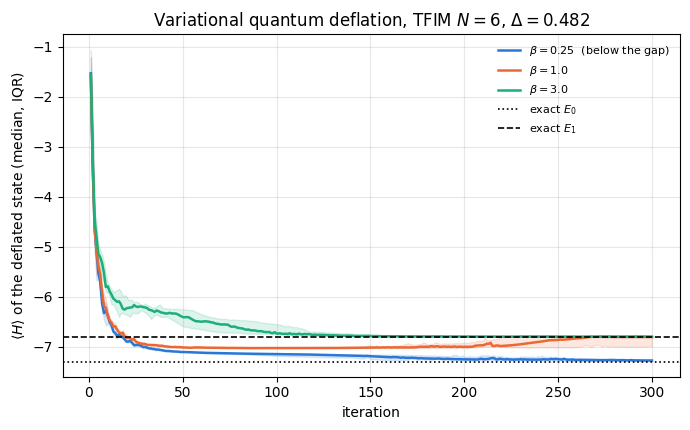

In [18]:
# ==============================================================================
# STEP 14: deflation for the first excited state of the critical Ising chain
# ==============================================================================
i_best = int(np.argmin(HIST[i_tfim, :, -1, 0]))
theta_star = TH_FINAL[i_tfim][i_best]
psi_star = ansatz_state(theta_star)
E_star = float(energy(model_terms(N_SITES, c_tfim), psi_star))
print(f"deflation anchor: best VQE ground state of the TFIM, E = {E_star:.6f} "
      f"(exact E_0 = {EXACT['TFIM']['E0']:.6f}, error {E_star - EXACT['TFIM']['E0']:.2e}), "
      f"F = {float(fidelity_pure(psi0_tfim, psi_star)):.4f}")
gap_tfim = EXACT["TFIM"]["E1"] - EXACT["TFIM"]["E0"]
print(f"exact gap Delta = {gap_tfim:.6f};  Eq. (12) requires beta > Delta")

R_VQD, T_VQD = 12, 300
th_v, ks_v = random_starts(R_VQD, n_main, seed=61)
BETAS = (0.25, 1.0, 3.0)


def vqd_run(beta):
    """Train R_VQD restarts on the deflated cost, Eq. (11); monitor (E of the state, overlap with psi_star)."""
    def cost(t):
        psi = ansatz_state(t)
        return energy(model_terms(N_SITES, c_tfim), psi) + beta * fidelity_pure(psi_star, psi)

    def monitor(t):
        psi = ansatz_state(t)
        return jnp.stack([energy(model_terms(N_SITES, c_tfim), psi), fidelity_pure(psi_star, psi),
                          fidelity_pure(EXACT["TFIM"]["psi1"], psi), parity(psi)])

    return jax.vmap(lambda t, k: train(t, k, grad_exact(cost), opt_adam(LR_BEST), monitor, T_VQD)[1])(th_v, ks_v)


print(f"\n{'beta':>6s} {'beta > gap?':>12s} {'median E':>10s} {'best E':>10s} {'exact E_1':>10s} "
      f"{'median overlap':>15s} {'median F with |1>':>18s} {'median parity':>14s}")
vqd_hist = {}
for beta in BETAS:
    h = np.asarray(jax.block_until_ready(jax.jit(vqd_run)(beta)))
    vqd_hist[beta] = h
    print(f"{beta:6.2f} {str(beta > gap_tfim):>12s} {np.median(h[:, -1, 0]):10.5f} {h[:, -1, 0].min():10.5f} "
          f"{EXACT['TFIM']['E1']:10.5f} {np.median(h[:, -1, 1]):15.2e} {np.median(h[:, -1, 2]):18.4f} "
          f"{np.median(h[:, -1, 3]):+14.4f}")

# --- per-run view: the deflated cost C_1 = E + beta * overlap, and a parity lower bound on E ---------------------
# For any state, E >= w_+ E_0 + w_- E_1 with w_+ = (1 + <P>)/2, because the lowest P = -1 level is E_1 (Section 11's
# table).  This bound uses only the measured parity and holds for every run, converged or not.
E1_tf, E0_tf = EXACT["TFIM"]["E1"], EXACT["TFIM"]["E0"]
print(f"\n{'beta':>6s} {'runs with overlap > 0.1':>24s} | best-energy run: {'E':>9s} {'C_1':>9s} {'overlap':>8s} "
      f"{'<P>':>7s} {'parity bound on E':>18s}")
for beta in BETAS:
    fin = vqd_hist[beta][:, -1, :]
    C1 = fin[:, 0] + beta * fin[:, 1]
    w_plus = (1 + fin[:, 3]) / 2
    bound = w_plus * E0_tf + (1 - w_plus) * E1_tf
    assert np.all(fin[:, 0] >= bound - 1e-9), "parity bound violated"
    r = int(np.argmin(fin[:, 0]))
    print(f"{beta:6.2f} {int(np.sum(fin[:, 1] > 0.1)):>18d} / {R_VQD} | {'':>16s} {fin[r, 0]:9.4f} {C1[r]:9.4f} "
          f"{fin[r, 1]:8.3f} {fin[r, 3]:+7.3f} {bound[r]:18.4f}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
for j, beta in enumerate(BETAS):
    lo, med, hi = bands(vqd_hist[beta][:, :, 0])
    ax.fill_between(np.arange(1, T_VQD + 1), lo, hi, color=PALETTE[j], alpha=0.15)
    ax.plot(np.arange(1, T_VQD + 1), med, "-", lw=1.8, color=PALETTE[j],
            label=fr"$\beta={beta}$" + ("" if beta > gap_tfim else "  (below the gap)"))
ax.axhline(EXACT["TFIM"]["E0"], color="k", ls=":", lw=1.2, label=r"exact $E_0$")
ax.axhline(EXACT["TFIM"]["E1"], color="k", ls="--", lw=1.2, label=r"exact $E_1$")
ax.set_xlabel("iteration"); ax.set_ylabel(r"$\langle H\rangle$ of the deflated state (median, IQR)")
ax.set_title(f"Variational quantum deflation, TFIM $N={N_SITES}$, $\\Delta={gap_tfim:.3f}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Below the threshold of Eq. (12) the method fails in the predicted way.** With $\beta=0.25<\Delta$
the deflated minimisation returns the *ground* state again: median energy $-7.276$, median overlap with the anchor
$0.994$, fidelity with the exact first excited state $0.0003$, parity $+0.998$. The penalty is simply not large
enough to lift $E_0+\beta$ above $E_1$, so the minimiser of Eq. (11) is still the ground state, exactly as the
derivation says.

**Above the threshold it works.** With $\beta=3$ the median energy is $-6.7998$ against the exact
$E_1=-6.81408$ — an error of $0.014$ — the median overlap with the anchor has fallen to $1.1\cdot10^{-3}$, the median
fidelity with the true first excited state is $0.993$, and the parity is $-0.9925$. The method has not only found
the first excited energy, it has found it in the **odd** parity sector, which is where the exact $\vert\psi_1\rangle$
lives (Section 11's table). Nothing in the algorithm was told about parity.

**Just above the threshold the deflated landscape is shallow.** At $\beta=1\approx2\Delta$ the median run finds the
excited state (median energy $-6.807$, fidelity $0.90$ with $\vert\psi_1\rangle$, parity $-0.91$), but the best
*energy* among the twelve runs, $E=-7.024$, lies $0.21$ below $E_1$. The per-run table identifies that run: its
overlap with the anchor is $0.50$ and its parity $+0.08$, so its deflated cost $C_1=E+\beta\times\text{overlap}=-6.52$
is $0.29$ *above* the minimum $E_1$ of Eq. (11). It is an unconverged run of the deflated minimisation, roughly an
equal mixture of the two parity sectors, and it is one of five runs at $\beta=1$ that end with an overlap above
$0.1$ with the anchor. Its energy is consistent with the parity bound $E\ge w_+E_0+w_-E_1$ printed next to it, as every
run's is. The anchor itself is not the problem: it has fidelity $0.9987$ with $\vert\psi_0\rangle$, which can
shift the minimum of $C_1$ by an amount of order $\beta(1-F)\approx10^{-3}$, far below $0.2$. The driving term that
pushes a run out of the ground-state sector is the excess $\beta-\Delta$ of Eq. (12): $0.52$ at $\beta=1$ against
$2.52$ at $\beta=3$, where no run ends with an overlap above $0.1$, the median overlap with the anchor drops a further
factor of $30$, and the best run, $-6.81085$, sits just above $E_1$. **Equation (12) is necessary; a penalty well
above the gap is what makes the deflated minimisation converge in a fixed budget.** On hardware, where neither $E_1$
nor $\vert\psi_0\rangle$ is known, the measured $C_1$ and the measured overlap are the quantities to report, because
a low energy with a large overlap is not an excited state.

## 13. Shot noise: SPSA against parameter shift at equal measurement budget

On hardware the energy is not evaluated, it is **estimated** from a finite number of projective measurements. For the
transverse-field Ising Hamiltonian two measurement settings suffice, because the $Z$-type terms all commute with one
another and so do the $X$-type terms (notebook 40, Section 12): measure every qubit in $Z$ to get all
$\langle Z_qZ_{q+1}\rangle$ at once, and every qubit in $X$ to get all $\langle X_q\rangle$ at once. With $M$ shots
split evenly, the estimator is unbiased with variance $\propto1/M$.

The comparison that matters on hardware is at **equal total number of shots**. Notebook 41 compared the two gradient
rules at equal iteration count and found parameter shift ahead, and noted that this does not answer the budget
question. Here we compare at equal budget, each rule at its own step size from a five-point scan. With $n$ angles,

* a parameter-shift iteration costs $2n$ circuits, hence $2nM$ shots;
* an SPSA iteration costs $2$ circuits, hence $2M$ shots.

At a fixed total budget $B$ the parameter-shift method may take $T_{\text{PS}}=B/(2nM)$ iterations and SPSA may take
$T_{\text{SPSA}}=n\,T_{\text{PS}}$ — a factor $n$ more steps with the same shots. The question is whether many cheap
noisy steps beat few accurate ones. The diagnostic plotted is always the **exact** energy error of the current
angles, which the optimiser never sees.

In [19]:
# ==============================================================================
# STEP 15: shot-noise estimators for the Ising energy (N = 4)
# ==============================================================================
N_SN, L_SN, H_SN, JZZ_SN = 4, 2, 1.0, -1.0
n_sn = hea_num_params(N_SN, L_SN)
c_sn = jnp.asarray((0.0, 0.0, JZZ_SN, H_SN), dtype=RDTYPE)
terms_sn = model_terms(N_SN, c_sn)
E0_SN, _ = lanczos_ground_state(terms_sn, N_SN)
E0_SN_dense = float(np.min(np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms_sn, N_SN)))))
print(f"TFIM N={N_SN}, h={H_SN}: E_0 = {E0_SN:.9f} (Lanczos) vs {E0_SN_dense:.9f} (dense), "
      f"difference {abs(E0_SN - E0_SN_dense):.1e}")
assert abs(E0_SN - E0_SN_dense) < 1e-8


def energy_shots(key, psi, shots):
    """Unbiased estimate of <H_TFIM> from `shots` projective measurements, Eq. (6) with Jxx=Jyy=0.

    PROTOCOL  half the shots measure every qubit in Z (all Z_q Z_{q+1} at once), half in X (all X_q at once).
    IMPL      `sample_bitstrings` returns bits of shape (shots, N); z = 1 - 2*bit are the +-1 eigenvalues.
    COST      2 circuit executions of shots/2 repetitions each.
    """
    kz, kx = jax.random.split(key)
    half = shots // 2
    z = 1.0 - 2.0 * sample_bitstrings(kz, psi, half, bases="Z" * N_SN).astype(RDTYPE)
    x = 1.0 - 2.0 * sample_bitstrings(kx, psi, half, bases="X" * N_SN).astype(RDTYPE)
    return JZZ_SN * jnp.mean(jnp.sum(z[:, :-1] * z[:, 1:], axis=1)) + H_SN * jnp.mean(jnp.sum(x, axis=1))


# --- CHECKPOINT: the shot estimator is unbiased and its spread falls as M^{-1/2} -------------------
theta_chk = random_starts(1, n_sn, seed=71)[0][0]
psi_chk = hardware_efficient_ansatz(theta_chk, N_SN, L_SN)
E_chk = float(energy(terms_sn, psi_chk))
# predicted single-shot constant sigma = sqrt(M Var) = sqrt(2 [Var(A) + Var(B)]) (notebook 40, Eq. (27)), computed
# EXACTLY from the outcome distributions of the two settings -- no sampling involved
bits = (np.arange(2 ** N_SN)[:, None] >> (N_SN - 1 - np.arange(N_SN))) & 1        # C order: qubit 0 = top bit
zv = 1 - 2 * bits                                                                # +-1 eigenvalues per outcome
A_val = JZZ_SN * np.sum(zv[:, :-1] * zv[:, 1:], axis=1)                          # Z setting: sum of Z Z bonds
B_val = H_SN * np.sum(zv, axis=1)                                                # X setting: sum of X_q
pz = np.abs(np.asarray(psi_chk).reshape(-1)) ** 2
psi_x = psi_chk
for q in range(N_SN):
    psi_x = apply_gate(psi_x, jnp.asarray([[1, 1], [1, -1]], dtype=CDTYPE) / np.sqrt(2), [q])   # rotate to X basis
px = np.abs(np.asarray(psi_x).reshape(-1)) ** 2
var_A, var_B = pz @ A_val ** 2 - (pz @ A_val) ** 2, px @ B_val ** 2 - (px @ B_val) ** 2
sigma_pred = np.sqrt(2 * (var_A + var_B))
print(f"\nexact <H> at a random parameter vector = {E_chk:.6f};  from the two outcome distributions: "
      f"{pz @ A_val + px @ B_val:.6f}")
print(f"predicted std x sqrt(M) = sqrt(2 [Var A + Var B]) = {sigma_pred:.4f};  "
      f"wrong control without the factor 2 (all M shots in each setting): {np.sqrt(var_A + var_B):.4f}")
assert abs(pz @ A_val + px @ B_val - E_chk) < 1e3 * TOL
N_REP = 300
print(f"{'shots M':>9s} {'mean of 300 estimates':>23s} {'z of mean':>10s} {'std x sqrt(M)':>15s} "
      f"{'z vs prediction':>16s} {'z vs control':>13s}")
for M in (32, 128, 512, 2048):
    ests = np.asarray(jax.vmap(lambda k: energy_shots(k, psi_chk, M))(jax.random.split(jax.random.PRNGKey(73), N_REP)))
    s_hat = ests.std(ddof=1) * np.sqrt(M)
    se_s = s_hat / np.sqrt(2 * (N_REP - 1))                    # standard error of a sample std (Gaussian approx.)
    z_mean = (ests.mean() - E_chk) / (sigma_pred / np.sqrt(M * N_REP))
    z_pred, z_ctrl = (s_hat - sigma_pred) / se_s, (s_hat - np.sqrt(var_A + var_B)) / se_s
    print(f"{M:9d} {ests.mean():23.5f} {z_mean:+10.2f} {s_hat:15.4f} {z_pred:+16.2f} {z_ctrl:+13.2f}")
    assert abs(z_mean) < 3.5 and abs(z_pred) < 3.5 and abs(z_ctrl) > 3.5

TFIM N=4, h=1.0: E_0 = -4.758770483 (Lanczos) vs -4.758770483 (dense), difference 0.0e+00



exact <H> at a random parameter vector = 0.723708;  from the two outcome distributions: 0.723708
predicted std x sqrt(M) = sqrt(2 [Var A + Var B]) = 3.2679;  wrong control without the factor 2 (all M shots in each setting): 2.3108
  shots M   mean of 300 estimates  z of mean   std x sqrt(M)  z vs prediction  z vs control


       32                 0.73792      +0.43          3.2474            -0.15         +7.05


      128                 0.71198      -0.70          3.1821            -0.66         +6.70


      512                 0.70852      -1.82          3.3814            +0.82         +7.74


     2048                 0.72068      -0.73          3.2505            -0.13         +7.07


equal budget B = 184320 shots per run:
  parameter shift + Adam : 60 iterations x 48 circuits x 64 shots
  SPSA + Adam            : 1440 iterations x 2 circuits x 64 shots



 step size  parameter shift, median final   SPSA, median final
     0.003                         3.4366               0.6072
      0.01                         1.2109               0.3453
      0.03                         0.3371               0.5641
       0.1                         0.3295               1.2970
       0.3                         0.5110               3.2958
selected step sizes: parameter shift 0.1, SPSA 0.01


  (12 training batches in 27.0 s, compilation included)



                      method  iterations   shots used   median final E-E_0       best
      parameter shift + Adam          60       184320              0.32949    0.20756
                 SPSA + Adam        1440       184320              0.34528    0.26284
 parameter shift, exact cost          60            0              0.20385    0.06694
            SPSA, exact cost        1440            0              0.22156    0.01926
  exact gradient, 2000 iters        2000            0              0.00149    0.00148
(the last row is the ansatz floor: what this circuit family can do at N=4, L=2 with no budget limit)



restarts: parameter shift worst 0.4063, SPSA best 0.2628;  permutation p-value 0.5140


control (the same test against SPSA at the untuned step 0.1, a real difference): p-value 0.0030


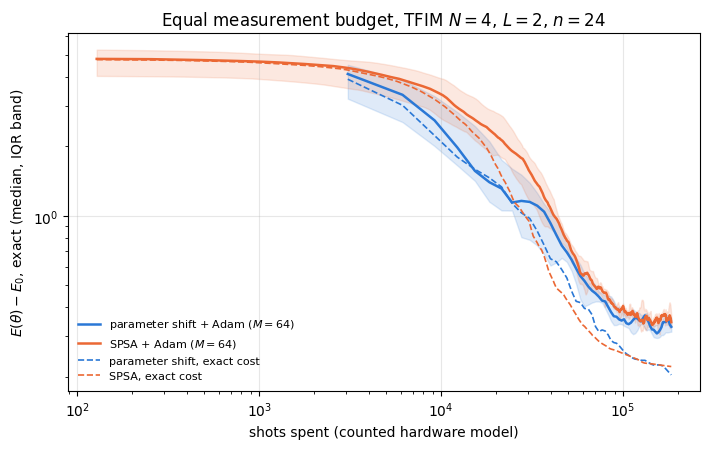

In [20]:
# ==============================================================================
# STEP 16: the two gradient rules with shots, and the equal-budget comparison
# ==============================================================================
def grad_ps_shots(M):
    """Parameter-shift gradient in which each of the 2n circuits is estimated from M shots (notebook 40, Eq. (18))."""
    eye = jnp.eye(n_sn)

    def rule(theta, key, k):
        kp, km = jax.random.split(key)

        def one(e, k1, k2):
            cp = energy_shots(k1, hardware_efficient_ansatz(theta + (jnp.pi / 2) * e, N_SN, L_SN), M)
            cm = energy_shots(k2, hardware_efficient_ansatz(theta - (jnp.pi / 2) * e, N_SN, L_SN), M)
            return (cp - cm) / 2
        return jax.vmap(one)(eye, jax.random.split(kp, n_sn), jax.random.split(km, n_sn))
    return rule


def grad_spsa_shots(M, c=0.2, gamma=0.101):
    """SPSA gradient rule with both circuits estimated from M shots."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        kd, kp, km = jax.random.split(key, 3)
        delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
        cp = energy_shots(kp, hardware_efficient_ansatz(theta + c_k * delta, N_SN, L_SN), M)
        cm = energy_shots(km, hardware_efficient_ansatz(theta - c_k * delta, N_SN, L_SN), M)
        return (cp - cm) / (2 * c_k) * delta
    return rule


err_sn = jax.jit(lambda t: energy(terms_sn, hardware_efficient_ansatz(t, N_SN, L_SN)) - E0_SN)
R_SN, M_SN, T_PS = 8, 64, 60
T_SPSA = n_sn * T_PS                                   # same total shots: 2 n M T_PS  =  2 M T_SPSA
BUDGET = 2 * n_sn * M_SN * T_PS
th_sn, ks_sn = random_starts(R_SN, n_sn, seed=81)
print(f"equal budget B = {BUDGET} shots per run:")
print(f"  parameter shift + Adam : {T_PS} iterations x {2 * n_sn} circuits x {M_SN} shots")
print(f"  SPSA + Adam            : {T_SPSA} iterations x 2 circuits x {M_SN} shots")

# each gradient rule gets its own step size, chosen on the noisy runs from a three-point grid (Section 7's lesson)
cost_sn = lambda t: energy(terms_sn, hardware_efficient_ansatz(t, N_SN, L_SN))
LR_SN = (0.003, 0.01, 0.03, 0.1, 0.3)
t0 = time.perf_counter()
noisy = {}
for lr in LR_SN:
    noisy[("ps", lr)] = np.asarray(train_many(th_sn, ks_sn, grad_ps_shots(M_SN), opt_adam(lr), err_sn, T_PS)[1])
    noisy[("spsa", lr)] = np.asarray(train_many(th_sn, ks_sn, grad_spsa_shots(M_SN), opt_adam(lr), err_sn, T_SPSA)[1])
print(f"\n{'step size':>10s} {'parameter shift, median final':>30s} {'SPSA, median final':>20s}")
for lr in LR_SN:
    print(f"{lr:10.3g} {np.median(noisy[('ps', lr)][:, -1]):30.4f} {np.median(noisy[('spsa', lr)][:, -1]):20.4f}")
LR_PS = min(LR_SN, key=lambda lr: np.median(noisy[("ps", lr)][:, -1]))
LR_SP = min(LR_SN, key=lambda lr: np.median(noisy[("spsa", lr)][:, -1]))
print(f"selected step sizes: parameter shift {LR_PS}, SPSA {LR_SP}")
h_ps, h_sp = noisy[("ps", LR_PS)], noisy[("spsa", LR_SP)]
h_ps_ex = np.asarray(train_many(th_sn, ks_sn, grad_exact(cost_sn), opt_adam(LR_PS), err_sn, T_PS)[1])
h_sp_ex = np.asarray(train_many(th_sn, ks_sn, grad_spsa(cost_sn, c=0.2), opt_adam(LR_SP), err_sn, T_SPSA)[1])
print(f"  ({2 * len(LR_SN) + 2} training batches in {time.perf_counter() - t0:.1f} s, compilation included)")

_, h_floor = train_many(th_sn, ks_sn,
                        grad_exact(lambda t: energy(terms_sn, hardware_efficient_ansatz(t, N_SN, L_SN))),
                        opt_adam(0.1), err_sn, 2000)
h_floor = np.asarray(h_floor)

print(f"\n{'method':>28s} {'iterations':>11s} {'shots used':>12s} {'median final E-E_0':>20s} {'best':>10s}")
for lab, h, T, sh in (("parameter shift + Adam", h_ps, T_PS, BUDGET),
                      ("SPSA + Adam", h_sp, T_SPSA, BUDGET),
                      ("parameter shift, exact cost", h_ps_ex, T_PS, 0),
                      ("SPSA, exact cost", h_sp_ex, T_SPSA, 0),
                      ("exact gradient, 2000 iters", h_floor, 2000, 0)):
    print(f"{lab:>28s} {T:11d} {sh if sh else 0:12d} {np.median(h[:, -1]):20.5f} {h[:, -1].min():10.5f}")
print(f"(the last row is the ansatz floor: what this circuit family can do at N={N_SN}, L={L_SN} with no budget limit)")
print(f"\nrestarts: parameter shift worst {h_ps[:, -1].max():.4f}, SPSA best {h_sp[:, -1].min():.4f};  "
      f"permutation p-value {perm_pvalue(h_ps[:, -1], h_sp[:, -1], seed=5):.4f}")
p_ctrl = perm_pvalue(h_ps[:, -1], noisy[("spsa", 0.1)][:, -1], seed=6)
print(f"control (the same test against SPSA at the untuned step 0.1, a real difference): p-value {p_ctrl:.4f}")
assert p_ctrl < 0.01

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for j, (lab, h, T) in enumerate((("parameter shift + Adam", h_ps, T_PS), ("SPSA + Adam", h_sp, T_SPSA))):
    shots_axis = np.arange(1, T + 1) * (2 * n_sn * M_SN if j == 0 else 2 * M_SN)
    lo, med, hi = bands(np.maximum(h, 1e-12))
    ax.fill_between(shots_axis, lo, hi, color=PALETTE[j], alpha=0.15)
    ax.loglog(shots_axis, med, "-", lw=1.8, color=PALETTE[j], label=lab + f" ($M={M_SN}$)")
for j, (lab, h, T) in enumerate((("parameter shift, exact cost", h_ps_ex, T_PS), ("SPSA, exact cost", h_sp_ex, T_SPSA))):
    shots_axis = np.arange(1, T + 1) * (2 * n_sn * M_SN if j == 0 else 2 * M_SN)
    _, med, _ = bands(np.maximum(h, 1e-12))
    ax.loglog(shots_axis, med, "--", lw=1.2, color=PALETTE[j], label=lab)
ax.set_xlabel("shots spent (counted hardware model)")
ax.set_ylabel(r"$E(\theta)-E_0$, exact (median, IQR band)")
ax.set_title(f"Equal measurement budget, TFIM $N={N_SN}$, $L={L_SN}$, $n={n_sn}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**The estimator behaves as derived.** The exact single-shot constant of notebook 40, Eq. (27), computed from the
two outcome distributions without sampling, is $\sqrt{2[\mathrm{Var}A+\mathrm{Var}B]}=3.268$, and the measured
std $\times\sqrt M$ agrees with it within $0.9$ standard errors at all four budgets, a factor of $64$ in $M$. The
means agree with the exact energy within $1.9$ standard errors. The wrong control, a protocol that forgets that each
setting receives only half the shots ($2.311$), is rejected at $6.7$ to $7.7$ standard errors.

**At equal measurement budget and tuned step sizes, the two gradient rules tie.** With $B=184320$ shots per run, spent
either as $60$ parameter-shift iterations or as $1440$ SPSA iterations, the step-size scan matters more than the
choice of method: SPSA is best at $\eta=0.01$ and parameter shift at $\eta=0.1$, and at a common $\eta=0.1$ SPSA would
have looked four times worse ($1.297$ against $0.329$). At their own best step sizes the median final errors are
$0.329$ (parameter shift) and $0.345$ (SPSA); the eight restarts interleave and the permutation test finds no
difference ($p=0.51$), while the same test does detect the untuned comparison ($p<0.01$, the control). SPSA wants a
step ten times smaller than parameter shift; it takes $24$ times as many steps, each along a single random direction.

**Shot noise costs both methods about the same.** The noise-free references, run with the same optimisers, step
sizes and iteration counts, give $0.204$ and $0.222$. Shot noise at $M=64$ adds about $0.12$ to both medians. Neither
the optimiser nor the estimator separates the two rules at this budget.

**Both are far from the ansatz floor.** With an exact gradient and $2000$ iterations the same circuit reaches
$1.5\cdot10^{-3}$, two orders of magnitude below what either method achieved with $1.8\cdot10^{5}$ shots. Most of
that gap is already present without shot noise: it is the price of being allowed only $60$ parameter-shift (or the
equivalent $1440$ SPSA) iterations. The budget limits the number of steps first and their accuracy second, which is
why [43 — VQE with classical shadows](../ch11_variational_quantum_circuits/43_vqe_with_classical_shadows.ipynb)
attacks the cost per energy estimate.

> **Numerical practice.** Every curve here is the **exact** energy error of the current angles, a quantity the
> optimiser never sees. On hardware only noisy estimates exist, and reporting the lowest estimate seen during
> training selects the most favourable fluctuation, which is biased low. A real experiment must re-measure its final
> answer with a much larger budget than it used during training.

## 14. Limits

Everything above was run on a simulator with $N\le6$ spins, where the exact answer is one Lanczos call away. Four
limits decide whether any of it scales.

**Barren plateaus.** Notebook 40 measured that the variance of one gradient component of a hardware-efficient circuit
over random angles falls by a factor of about $2^{1.6}$ to $2^{1.8}$ per added qubit for a global cost (notebook 40, Section 13.2), and only as $1/N^2$ for a
local cost at fixed depth. An energy is a sum of $O(N)$ local terms, so it is on the favourable side: notebook 42a,
Section 9, finds no decay at fixed depth, but a circuit whose depth grows with $N$ approaches the exponential
2-design value, and a gradient that is exponentially small must be resolved above shot noise that falls only as
$M^{-1/2}$. The remedy has to change the ansatz or the cost; a better optimiser does not help (McClean *et al.*, 2018; Cerezo
*et al.*, 2021). The random-angle initialisation used throughout this notebook is precisely the distribution the
plateau theorems assume.

**Measurement cost.** Every energy evaluation here was exact and free. On hardware, an accuracy $\varepsilon$ on
$\langle H\rangle$ costs $O(\lVert\mathbf c\rVert_1^2/\varepsilon^2)$ shots, and chemistry-scale Hamiltonians have
$O(N^4)$ terms. A single Adam iteration with a parameter-shift gradient costs $2n$ circuit families, each needing that
many shots. This is the dominant practical obstacle, and it is the subject of
[43 — VQE with classical shadows](../ch11_variational_quantum_circuits/43_vqe_with_classical_shadows.ipynb).

**Noise.** Real gates are imperfect, which biases the energy upwards and deforms the landscape. The variational
principle and Eqs. (4)–(5) still hold for the mixed state the device actually prepares (Section 3.3), so a measured
energy still certifies the fidelity of *that* state with the ground state; what noise destroys is the link between
the measured energy and the ideal circuit, and on top of it the finite-shot estimate of $E$ itself fluctuates and can
fall below $E_0$ by a few standard errors.

**What classical methods do better for these problems.** For a one-dimensional gapped chain the ground state obeys an
area law, and a matrix-product state with modest bond dimension represents it to machine precision; DMRG finds it in
seconds for hundreds of sites, far beyond anything demonstrated variationally on hardware
([18 — MPS and TEBD](../ch07_tensor_networks/18_mps_tebd.ipynb)). VQE on a one-dimensional spin chain is therefore a
*benchmark* rather than an application: it is the setting in which the algorithm can be validated against an exact answer,
which is exactly what this notebook did. The regimes where no good classical method exists — frustrated
two-dimensional magnets, real-time dynamics, strongly correlated chemistry — are also the regimes where the ansatz
design and the measurement cost are hardest.

## 15. Key takeaways

* **The variational principle is proved in three lines and works as a unit test.** Every trial state satisfies
  $\langle H\rangle\ge E_0$, Eq. (1). Across the $10800$ energies recorded in Section 8 the error never went
  negative, its smallest value being $1.6\cdot10^{-3}$.
* **The energy error is second order in the state error.** For every state
  $E-E_0=\langle\phi\vert(H-E_0)\vert\phi\rangle\le(E_{\max}-E_0)\lVert\phi\rVert^2$, Eq. (2a); for the controlled
  perturbation $E-E_0=K(1-F)$ held to $10^{-14}$ with $K=7.2096$ computed in advance. A state wrong at the $1\%$ level
  in amplitude gave an energy right to four digits.
* **For a unique ground state the gap converts an energy error into a certificate on the state**,
  $1-F\le(E-E_0)/\Delta$, Eq. (5), with the companion upper bound $(E_{\max}-E_0)(1-F)$; the two differ by a factor
  $30$ for the critical Ising chain, and both hold for mixed states. Where the gap closes the certificate says
  nothing: at $h=0.2$ it degenerates to $1-F\le1$.
* **Signs in the Pauli convention must be read off the correlators.** With $J_{xx}=-1$ the measured
  $\langle X_iX_{i+1}\rangle=+0.98$: the coupling is ferromagnetic along $x$. The XXZ and XY parameters put those
  chains in a nearly polarised phase with $0.05$ and $0.12$ bits of entanglement, while the ferromagnetic Ising chain
  at $h_x=1$ sits at its critical point with $0.47$ bits and a six times smaller gap.
* **The Hamiltonians have a $\mathbb Z_2$ parity $P=\prod_qX_q$ and no $U(1)$.** The measured
  $\lVert[H,P]\vert\phi\rangle\rVert$ was exactly zero, and $\lVert[H,S^z_{\text{tot}}]\vert\phi\rangle\rVert=4.41$
  for all three models, because the whole commutator comes from the transverse field.
* **The hardware-efficient ansatz breaks the symmetry and then largely relearns it.** At random angles the median
  symmetry leakage was $0.94$; after training $5\cdot10^{-4}$ to $1.2\cdot10^{-3}$, always below the bound
  $2(1-F)\le2(E-E_0)/\Delta$. Leakage tracks the energy error for the XXZ and XY chains and not for the Ising chain,
  whose residual error lies mostly inside the right sector. The Hamiltonian-variational ansatz has leakage
  $3\cdot10^{-15}$ at *any* angles, by construction.
* **The $10^{-2}$ plateau of the main runs is the optimiser's.** Continuing at the same Adam step left it in place;
  continuing at $\eta=0.1$ lowered the median errors four- to eightfold. Depth studies read against that floor: the
  critical Ising error fell from $0.213$ ($L=1$) to $0.012$ ($L=4$), and beyond $L=3$ no difference was significant.
* **The entanglement bound $S_{\text{half}}\le\min(L,N/2)$ follows from the Schmidt rank and is only a necessary
  condition.** At $L=1$ the circuit may carry one bit and the target needs $0.47$, yet the optimised state carried
  $0.013$ bits and missed the energy by $0.21$. The optimised states end slightly *below* the exact entanglement, far
  below the capacity, and $n\le84$ angles against $126$ for a general state sufficed for fidelity $0.997$.
* **Problem-inspired structure is worth an order of magnitude in parameters.** Started from the ground state of the
  field term, the Hamiltonian-variational ansatz reached a median of $0.017$ with $16$ angles where a $24$-angle
  hardware-efficient circuit managed $0.213$; at equal depth the hardware-efficient family wins.
* **Near a degeneracy, fidelity with "the" ground state is the wrong question.** At $h=0.2$ the VQE reached an
  energy error of $2\cdot10^{-4}$ with fidelity $0.5000$ and fidelity $0.9999$ with the doublet; parity $0.000$ and
  entropy $0.0001$ bits identify a symmetry-broken state, and Eq. (10) predicts the energy error from the parity at
  $h=0.4$ and $0.6$. The hardest field of the sweep was $h=0.8$, in the crossover below the critical point.
* **Deflation turns a minimiser into an excited-state solver above $\beta=\Delta$, and converges reliably well above
  it.** At $\beta=0.25<\Delta=0.482$ the ground state came back; at $\beta=1$ five of twelve runs stalled with an
  overlap above $0.1$ with the anchor (one at an energy below $E_1$, with $C_1$ far above it); at $\beta=3$ all runs reached the
  odd-parity first excited state, median fidelity $0.993$.
* **At equal measurement budget and tuned step sizes, parameter shift and SPSA tied** ($0.329$ against $0.345$,
  $p=0.51$); an untuned common step would have reported a factor of four. Both remain two orders of magnitude above
  the $1.5\cdot10^{-3}$ that the same circuit reaches without a budget.

## 16. Exercises

1. ★ **The bound in action.** Take the converged TFIM run of Section 8 and compute the certified infidelity bound
   $1-F\le(E-E_0)/\Delta$ of Eq. (5) from the measured energy error alone. Compare with the true infidelity. By what
   factor is the certificate loose, and why?
2. ★ **Antiferromagnetic couplings.** Flip the sign of $J_{xx}$ and $J_{yy}$ in the XXZ model. Predict the sign of
   $\langle X_iX_{i+1}\rangle$ in the exact ground state before you run it, then check. Does the VQE find it as easily?
3. ★★ **A symmetry-preserving hardware-style ansatz (extend the code).** Build a layered circuit from $R_x$
   rotations on every qubit and $R_{ZZ}$ and $R_{YY}$ gates on every bond, started from $\vert-\rangle^{\otimes N}$.
   Show analytically that every gate commutes with $P=\prod_qX_q$, so the symmetry leakage of Eq. (8) is zero by
   construction, and explain why $R_x$ and $R_{XX}$ alone would be useless (they all commute with each other and leave
   $\vert-\rangle^{\otimes N}$ unchanged up to a phase). Measure the energy error for the three models at a
   parameter count comparable to the hardware-efficient $L=4$ circuit.
4. ★★ **The initial state of the Hamiltonian-variational ansatz.** Repeat the scan of Section 10.3 with the circuit
   started from $\vert+\rangle^{\otimes N}$ instead of $\vert-\rangle^{\otimes N}$. Compute the energy of the two
   starting states first, then compare the median errors depth by depth, and explain the difference from the role of
   the initial state in adiabatic state preparation.
5. ★★ **Deflation to the second excited state.** Extend Eq. (11) with a second penalty term
   $\beta_1\lvert\langle\psi_1^\star\vert\psi\rangle\rvert^2$ and find $E_2$. Derive the condition on the two penalties
   analogous to Eq. (12) and verify it numerically by scanning $\beta$.
6. ★★ **The hardest field at larger $N$ (physics).** Repeat Section 11 for $N=8$ and $N=10$ at fixed $L$. Does the peak
   of the energy error follow the critical point, and does the width of the difficult region shrink with $N$?
7. ★★★ **Order parameter without symmetry breaking (physics).** In the ordered phase the magnetisation
   $\langle Z_q\rangle$ vanishes in the exact finite-$N$ ground state even though the system is ordered. Compute the
   correlator $\langle Z_0Z_{N-1}\rangle$ instead, for the exact state and for the VQE states of Section 11, and
   explain why it is the right diagnostic there.
8. ★★★ **The shot budget of the whole calculation (physics).** From Section 13, extrapolate the number of shots needed
   to reach a chemical-accuracy energy error ($1.6\cdot10^{-3}$ Hartree, here read as $10^{-3}$ in units of $J$) for
   $N=6$ with $L=4$. Combine with the gradient-variance measurements of notebook 40 and of notebook 42a, Section 9, to estimate how that budget grows with
   $N$, and say at which $N$ it exceeds a day of machine time.

## References

* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first VQE
  experiment.
* J. R. McClean, J. Romero, R. Babbush and A. Aspuru-Guzik, *The theory of variational hybrid quantum-classical
  algorithms*, New J. Phys. **18**, 023023 (2016) — the general framework, and the variational principle in this
  setting.
* A. Kandala, A. Mezzacapo, K. Temme, M. Takita, M. Brink, J. M. Chow and J. M. Gambetta, *Hardware-efficient
  variational quantum eigensolver for small molecules and quantum magnets*, Nature **549**, 242 (2017) — the
  hardware-efficient ansatz family (layers of single-qubit Euler rotations and a fixed entangler); the circuit used
  here is a variant with $R_yR_z$ rotations and $CZ$ entanglers.
* D. Wecker, M. B. Hastings and M. Troyer, *Progress towards practical quantum variational algorithms*, Phys. Rev. A
  **92**, 042303 (2015) — the Hamiltonian-variational ansatz.
* W. W. Ho and T. H. Hsieh, *Efficient variational simulation of non-trivial quantum states*, SciPost Phys. **6**, 029
  (2019) — alternating Ising and field evolutions, the ansatz family of Eq. (13), prepare the GHZ state and the
  critical transverse-field Ising ground state of an $N$-site ring exactly with $N/2$ layers.
* O. Higgott, D. Wang and S. Brierley, *Variational quantum computation of excited states*, Quantum **3**, 156 (2019)
  — variational quantum deflation: the penalised cost of our Eq. (11) (their Eq. (2)) and the sufficient condition
  $\beta_i>E_k-E_i$ on the penalty weights, our Eq. (12).
* J. Tilly, H. Chen, S. Cao, D. Picozzi, K. Setia, Y. Li, E. Grant, L. Wossnig, I. Rungger, G. H. Booth and
  J. Tennyson, *The variational quantum eigensolver: a review of methods and best practices*, Phys. Rep. **986**, 1
  (2022) — the comprehensive review.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — ansatz design,
  trainability and barren plateaus.
* J. R. McClean, S. Boixo, V. N. Smelyanskiy, R. Babbush and H. Neven, *Barren plateaus in quantum neural network
  training landscapes*, Nat. Commun. **9**, 4812 (2018) — the exponential concentration of gradients.
* M. Larocca, N. Ju, D. García-Martín, P. J. Coles and M. Cerezo, *Theory of overparametrization in quantum neural
  networks*, Nat. Comput. Sci. **3**, 542 (2023) — overparametrisation sets in when the rank of the quantum Fisher
  information saturates, at most at the dimension of the dynamical Lie algebra and, for a pure state, at
  $2\cdot2^N-2$; the threshold used in Section 10.2.
* S. Sachdev, *Quantum Phase Transitions*, 2nd ed., Cambridge University Press (2011) — the transverse-field Ising
  chain, its critical point and the symmetry-broken doublet of Section 11.
* P. Calabrese and J. Cardy, *Entanglement entropy and quantum field theory*, J. Stat. Mech. (2004) P06002 — the
  logarithmic growth of the entanglement entropy at a critical point, $(c/6)\log$ for an open chain.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/